# Part 0: Load in Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import localcider
from localcider.sequenceParameters import SequenceParameters
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
import pathlib
from matplotlib import font_manager
from scipy.stats import fisher_exact


# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#077a15'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#86bd8d'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#1725c2'
COLOR_MAP['P']         = '#c25fc9'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

/home/research/kiersten.ruff/fonts/ARIAL.TTF


# Part 1: Get and Analyze IDR clusters

## 1.1 - Load in IDR information

In [3]:
humandf=pd.read_excel('../general_data/All_sapiens_IDRs_clustermap_using_centroids.xlsx')

print(humandf.isnull().any())
humandf = humandf.fillna('')

fullaccs=humandf['Uniprot'].tolist()
fullaccswnums=humandf['Uniprot w IDRnum'].tolist()
fullgeneswnums=humandf['Gene'].tolist()
fullclusternum=humandf['Cluster Number'].tolist()
fullseqlens=humandf['IDR Length'].tolist()
fullstpos=humandf['Start Pos'].tolist()
fullenpos=humandf['End Pos'].tolist()
fullproteinlength=humandf['Full Protein Length'].tolist()
fullmininterclustdist=humandf['Min Inter Clust Dist'].tolist()
fulltermini=humandf['IDR Position'].tolist()
fulllocationbyunistring=humandf['HPA Location'].tolist()
fullseqs=humandf['Sequence'].tolist()

print(humandf)


Unnamed: 0              False
Uniprot                 False
Uniprot w IDRnum        False
Gene                    False
Cluster Number          False
IDR Length              False
Start Pos               False
End Pos                 False
Full Protein Length     False
Min Inter Clust Dist    False
IDR Position            False
HPA Location             True
Sequence                False
dtype: bool
       Unnamed: 0 Uniprot Uniprot w IDRnum            Gene  Cluster Number  \
0               0  G5E9R7         G5E9R7_1  KRTAP4-16 IDR1              27   
1               1  Q9NRJ4         Q9NRJ4_1      TULP4 IDR1              17   
2               2  Q9NRJ4         Q9NRJ4_2      TULP4 IDR2               1   
3               3  Q9NRJ4         Q9NRJ4_3      TULP4 IDR3              27   
4               4  Q9NRJ4         Q9NRJ4_4      TULP4 IDR4              27   
...           ...     ...              ...             ...             ...   
24503       24503  Q7Z739         Q7Z739_2     YTHDF

## 1.2 - Load in IDR z-score data

In [3]:
# make sure features match
myfeat=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly','Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']
print(len(myfeat))

# Load in z-scores for all human IDRs
# Made in /project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/map_clusters_for_all_human_IDRs.ipynb
fullzvec=np.load('../general_data/sapiens_full_idrome_gte_30_nardini_compositional_RtoK.npy')
print(fullzvec.shape)

90
(24508, 90)


## 1.3 - Create subset of IDRs that want to analyze - all IDRs length gte 70 and non-linker IDRs gte 50 in length and min inter cluster distance gte 1.5

In [4]:
minidrlength=50
minidrlinkerlength=70
mininterclustdist=1.5

subidrsdf=humandf[humandf['IDR Length']>=minidrlength]
subidrsdf=subidrsdf[ (subidrsdf['IDR Length']>=minidrlinkerlength) | (subidrsdf['IDR Position'].isin(['IDR','N-terminal IDR','C-terminal IDR'])) ]
subidrsdf=subidrsdf[subidrsdf['Min Inter Clust Dist']>=mininterclustdist]
print(subidrsdf.isnull().any())
subidrsdf = subidrsdf.fillna('')
print(subidrsdf)

subaccs=subidrsdf['Uniprot'].tolist()
subaccswnums=subidrsdf['Uniprot w IDRnum'].tolist()
subgeneswnums=subidrsdf['Gene'].tolist()
subclusters=subidrsdf['Cluster Number'].tolist()
subseqlens=subidrsdf['IDR Length'].tolist()
substpos=subidrsdf['Start Pos'].tolist()
subenpos=subidrsdf['End Pos'].tolist()
subproteinlength=subidrsdf['Full Protein Length'].tolist()
submininterclustdist=subidrsdf['Min Inter Clust Dist'].tolist()
subtermini=subidrsdf['IDR Position'].tolist()
subseqs=subidrsdf['Sequence'].tolist()
sublocstring=subidrsdf['HPA Location'].tolist()


sublocationbyunistring=sublocstring


Unnamed: 0              False
Uniprot                 False
Uniprot w IDRnum        False
Gene                    False
Cluster Number          False
IDR Length              False
Start Pos               False
End Pos                 False
Full Protein Length     False
Min Inter Clust Dist    False
IDR Position            False
HPA Location            False
Sequence                False
dtype: bool
       Unnamed: 0 Uniprot Uniprot w IDRnum            Gene  Cluster Number  \
0               0  G5E9R7         G5E9R7_1  KRTAP4-16 IDR1              27   
7               7  Q9NRJ4         Q9NRJ4_7      TULP4 IDR7              23   
8               8  Q5MIZ7         Q5MIZ7_1    PPP4R3B IDR1              18   
12             12  Q9NQ76         Q9NQ76_1       MEPE IDR1               4   
14             14  Q9NQ76         Q9NQ76_3       MEPE IDR3              24   
...           ...     ...              ...             ...             ...   
24495       24495  Q6ZSZ5         Q6ZSZ5_1   ARHGEF1

## 1.3b - Create subset of IDRs that want to analyze - all IDRs length gte 70 and non-linker IDRs gte 50 in length - used when don't care about cluster distance

In [5]:
subidrsdfNODIST=humandf[humandf['IDR Length']>=minidrlength]
subidrsdfNODIST=subidrsdfNODIST[ (subidrsdfNODIST['IDR Length']>=minidrlinkerlength) | (subidrsdfNODIST['IDR Position'].isin(['IDR','N-terminal IDR','C-terminal IDR'])) ]
print(subidrsdfNODIST.isnull().any())
subidrsdfNODIST = subidrsdfNODIST.fillna('')
print(subidrsdfNODIST)

subaccsNODIST=subidrsdfNODIST['Uniprot'].tolist()
subaccswnumsNODIST=subidrsdfNODIST['Uniprot w IDRnum'].tolist()
subgeneswnumsNODIST=subidrsdfNODIST['Gene'].tolist()
subclustersNODIST=subidrsdfNODIST['Cluster Number'].tolist()
subseqlensNODIST=subidrsdfNODIST['IDR Length'].tolist()
substposNODIST=subidrsdfNODIST['Start Pos'].tolist()
subenposNODIST=subidrsdfNODIST['End Pos'].tolist()
subproteinlengthNODIST=subidrsdfNODIST['Full Protein Length'].tolist()
submininterclustdistNODIST=subidrsdfNODIST['Min Inter Clust Dist'].tolist()
subterminiNODIST=subidrsdfNODIST['IDR Position'].tolist()
subseqsNODIST=subidrsdfNODIST['Sequence'].tolist()
sublocstringNODIST=subidrsdfNODIST['HPA Location'].tolist()


sublocationbyunistringNODIST=sublocstringNODIST

Unnamed: 0              False
Uniprot                 False
Uniprot w IDRnum        False
Gene                    False
Cluster Number          False
IDR Length              False
Start Pos               False
End Pos                 False
Full Protein Length     False
Min Inter Clust Dist    False
IDR Position            False
HPA Location            False
Sequence                False
dtype: bool
       Unnamed: 0 Uniprot Uniprot w IDRnum            Gene  Cluster Number  \
0               0  G5E9R7         G5E9R7_1  KRTAP4-16 IDR1              27   
7               7  Q9NRJ4         Q9NRJ4_7      TULP4 IDR7              23   
8               8  Q5MIZ7         Q5MIZ7_1    PPP4R3B IDR1              18   
12             12  Q9NQ76         Q9NQ76_1       MEPE IDR1               4   
14             14  Q9NQ76         Q9NQ76_3       MEPE IDR3              24   
...           ...     ...              ...             ...             ...   
24498       24498  Q6ZSZ5         Q6ZSZ5_4   ARHGEF1

## 1.4 Load in all human accessions

In [6]:
# The initial set of accessions used to extract IDRs from
tmp=pd.read_table('../general_data/ACCESSIONS_UP000005640_9606.txt')
accs_all_human=tmp['Uniprot'].tolist()
print(len(accs_all_human))
print(len(list(set(accs_all_human))))

20882
20882


# Part 2: Get enrichment of cluster by subcellular location

## 2.1 - Load in subcellular information from HPA

In [7]:
HPAtable=pd.read_table('../general_data/HPA/subcellular_location.tsv')

print(HPAtable)

tmp=HPAtable[HPAtable['Gene name']=='POLR2A']
print(tmp)

                  Gene        Gene name Reliability            Main location  \
0      ENSG00000000003           TSPAN6    Approved   Cell Junctions;Cytosol   
1      ENSG00000000457            SCYL3   Supported  Cytosol;Golgi apparatus   
2      ENSG00000000460         C1orf112    Approved             Mitochondria   
3      ENSG00000000938              FGR    Approved          Plasma membrane   
4      ENSG00000000971              CFH    Approved                 Vesicles   
...                ...              ...         ...                      ...   
13142  ENSG00000290292            HOMEZ   Supported                 Nucleoli   
13143  ENSG00000290315  ENSG00000290315    Approved      Cytosol;Nucleoplasm   
13144  ENSG00000290317  ENSG00000290317    Approved              Nucleoplasm   
13145  ENSG00000291237             SOD2   Supported             Mitochondria   
13146  ENSG00000291316  ENSG00000291316    Approved              Nucleoplasm   

             Additional location    Ext

## 2.2 - Get all unique locations

In [8]:
allloc=HPAtable['Main location'].tolist()
allens=HPAtable['Gene'].tolist()

uniqueloc=[]
for a in allloc:
    if isinstance(a,str):
        #print(a)
        tmp=a.split(';')
        #print(tmp)
        for i in tmp:
            if i not in uniqueloc:
                uniqueloc.append(i)

uniqueloc.sort(key=str.lower)            
print(uniqueloc)
print(len(uniqueloc))

print(len(allloc))
print(allloc[4980:4985])

for x in range(0,len(allloc)):
    if str(allloc[x])=='nan':
        allloc[x]='missing'
        
    
idx=[i for i, x in enumerate(allloc) if x=='missing']
print(idx)

print(allloc[4189])

['Actin filaments', 'Aggresome', 'Cell Junctions', 'Centriolar satellite', 'Centrosome', 'Cytokinetic bridge', 'Cytoplasmic bodies', 'Cytosol', 'Endoplasmic reticulum', 'Endosomes', 'Focal adhesion sites', 'Golgi apparatus', 'Intermediate filaments', 'Kinetochore', 'Lipid droplets', 'Lysosomes', 'Microtubule ends', 'Microtubules', 'Midbody', 'Midbody ring', 'Mitochondria', 'Mitotic chromosome', 'Mitotic spindle', 'Nuclear bodies', 'Nuclear membrane', 'Nuclear speckles', 'Nucleoli', 'Nucleoli fibrillar center', 'Nucleoli rim', 'Nucleoplasm', 'Peroxisomes', 'Plasma membrane', 'Rods & Rings', 'Vesicles']
34
13147
['Cytosol;Vesicles', 'Centrosome;Cytosol', 'Cytosol;Nucleoplasm', 'Nucleoplasm', 'Vesicles']
[4189]
missing


## 2.3 - Get accession for each location

In [9]:
# Load in mapping of accessions to ensemble
ens2uni=pd.read_table('../general_data/HPA/ENSEMBL_to_Uniprot_location_proteins_202312_no_duplicates.tsv')

unimap=ens2uni['Uniprot'].tolist()
ensmap=ens2uni['ENSEMBL'].tolist()
# mapping is bad for POLR2A so add it 
unimap.append('P24928')
ensmap.append('ENSG00000181222')


uniquelocacc=[[] for x in range(len(uniqueloc))]
mappedaccs=[]
count=0
for f in range(0,len(accs_all_human)):
    if accs_all_human[f] in unimap:
        idx=unimap.index(accs_all_human[f])
        if ensmap[idx] in allens:
            # Gets all accessions that can be mapped to HPA
            count=count+1
            mappedaccs.append(accs_all_human[f])
            
            # find index of ensembl accession in hpa data
            idx2=allens.index(ensmap[idx])
            
            for a in range(0,len(uniqueloc)):
                if uniqueloc[a] in allloc[idx2]:
                    if accs_all_human[f] not in uniquelocacc[a]:
                        uniquelocacc[a].append(accs_all_human[f])
                        #print(mygenes[f])
                        #print(subaccsNODIST[f])
                        #print(allloc[idx2])
                        #print(idx)
                        #hi

print(len(accs_all_human))
print('Number of mapped accessions '+str(count))
#print(uniquelocacc)

20882
Number of mapped accessions 12887


## 2.4 - Get subcellular location enrichment in IDRs

In [15]:
pvalsbylocation=np.zeros((len(uniqueloc)))
pvalsbylocationlog=np.zeros((len(uniqueloc)))
oddsratiobylocation=np.zeros((len(uniqueloc)))

for a in range(0,len(uniqueloc)):
    print(uniqueloc[a])
    sumallidrs=0
    
    # For each location determine if IDRs are enriched there
    subfeatureyes=0
    subfeatureno=0
    restfeatureyes=0
    restfeatureno=0
    
    for s in range(0,len(accs_all_human)):
        if accs_all_human[s] in mappedaccs:
            if accs_all_human[s] in uniquelocacc[a]: # if in location
                if accs_all_human[s] in subaccsNODIST: # if houses IDR
                        subfeatureyes=subfeatureyes+1
                        sumallidrs=sumallidrs+1
                else:
                    subfeatureno=subfeatureno+1
            else:
                if accs_all_human[s] in subaccsNODIST:
                    restfeatureyes=restfeatureyes+1
                else:
                    restfeatureno=restfeatureno+1
                
    print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

    # defining the table
    if subfeatureyes+restfeatureyes>0:
        data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
        print(data)
        # One-sided greater used to test if greater occurrence in nucleolus
        res = fisher_exact(data, alternative='greater')
        pvalsbylocation[a]=res[1]
        pvalsbylocationlog[a]=-math.log10(res[1])
        oddsratiobylocation[a]=res[0]
            
    print('Number of IDRs in '+uniqueloc[a]+' '+str(subfeatureyes+subfeatureno))
    print(sumallidrs)

print(pvalsbylocation)

Actin filaments
12887
[[65, 71], [4695, 8056]]
Number of IDRs in Actin filaments 136
65
Aggresome
12887
[[0, 4], [4760, 8123]]
Number of IDRs in Aggresome 4
0
Cell Junctions
12887
[[88, 104], [4672, 8023]]
Number of IDRs in Cell Junctions 192
88
Centriolar satellite
12887
[[45, 47], [4715, 8080]]
Number of IDRs in Centriolar satellite 92
45
Centrosome
12887
[[68, 140], [4692, 7987]]
Number of IDRs in Centrosome 208
68
Cytokinetic bridge
12887
[[8, 17], [4752, 8110]]
Number of IDRs in Cytokinetic bridge 25
8
Cytoplasmic bodies
12887
[[18, 25], [4742, 8102]]
Number of IDRs in Cytoplasmic bodies 43
18
Cytosol
12887
[[981, 1980], [3779, 6147]]
Number of IDRs in Cytosol 2961
981
Endoplasmic reticulum
12887
[[121, 335], [4639, 7792]]
Number of IDRs in Endoplasmic reticulum 456
121
Endosomes
12887
[[6, 10], [4754, 8117]]
Number of IDRs in Endosomes 16
6
Focal adhesion sites
12887
[[39, 49], [4721, 8078]]
Number of IDRs in Focal adhesion sites 88
39
Golgi apparatus
12887
[[245, 583], [4515, 75

## 2.5 - Save p-values

In [16]:
#np.savetxt('data/subcellular_location_HPA_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt', pvalsbylocationlog)
#np.savetxt('data/subcellular_location_HPA_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_odds_ratio.txt', oddsratiobylocation)

## 2.6 - Get subcellular location enrichment by GIN type

In [37]:
numkclusts=max(subclusters)+1

pvalsbylocation=np.zeros((len(uniqueloc),numkclusts))
pvalsbylocationlog=np.zeros((len(uniqueloc),numkclusts))
oddsratiobylocation=np.zeros((len(uniqueloc),numkclusts))

for a in range(0,len(uniqueloc)):
    print(uniqueloc[a])
    sumallidrs=0
    for c in range(0,numkclusts):
        print('Cluster_'+str(c))
        midx = [i for i, x in enumerate(subclusters) if x == c]
        
        topaccs=[]
        for i in midx:
            topaccs.append(subaccswnums[i])
        
        print('Number of IDRs: '+str(len(topaccs)))
    
        # For each location determine if that feature is enriched there
        subfeatureyes=0
        subfeatureno=0
        restfeatureyes=0
        restfeatureno=0
        for s in range(0,len(subaccs)):
            if subaccs[s] in mappedaccs:
                if subaccs[s] in uniquelocacc[a]:
                    if subaccswnums[s] in topaccs:
                        subfeatureyes=subfeatureyes+1
                        sumallidrs=sumallidrs+1
                    else:
                        subfeatureno=subfeatureno+1
                else:
                    if subaccswnums[s] in topaccs:
                        restfeatureyes=restfeatureyes+1
                    else:
                        restfeatureno=restfeatureno+1

        print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

        # defining the table
        if subfeatureyes+restfeatureyes>0:
            data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
            print(data)
            # One-sided greater used to test if greater occurrence in nucleolus
            res = fisher_exact(data, alternative='greater')
            print(res[1])
            pvalsbylocation[a,c]=res[1]
            pvalsbylocationlog[a,c]=-math.log10(res[1])
            oddsratiobylocation[a,c]=res[0]
            
    print('Number of IDRs in '+uniqueloc[a]+' '+str(subfeatureyes+subfeatureno))
    print(sumallidrs)

print(pvalsbylocation)

Actin filaments
Cluster_0
Number of IDRs: 244
6619
[[3, 86], [189, 6341]]
0.48007113011636854
Cluster_1
Number of IDRs: 313
6619
[[5, 84], [254, 6276]]
0.2685459008451494
Cluster_2
Number of IDRs: 101
6619
[[0, 89], [71, 6459]]
1.0
Cluster_3
Number of IDRs: 399
6619
[[1, 88], [327, 6203]]
0.9894801428149547
Cluster_4
Number of IDRs: 328
6619
[[6, 83], [250, 6280]]
0.12945296719280786
Cluster_5
Number of IDRs: 179
6619
[[2, 87], [138, 6392]]
0.5656385536453103
Cluster_6
Number of IDRs: 462
6619
[[3, 86], [373, 6157]]
0.8887550373154396
Cluster_7
Number of IDRs: 255
6619
[[1, 88], [204, 6326]]
0.9403421231020452
Cluster_8
Number of IDRs: 114
6619
[[2, 87], [93, 6437]]
0.36649178866386894
Cluster_9
Number of IDRs: 399
6619
[[6, 83], [309, 6221]]
0.2486186360990205
Cluster_10
Number of IDRs: 183
6619
[[2, 87], [158, 6372]]
0.6388754845856142
Cluster_11
Number of IDRs: 151
6619
[[0, 89], [115, 6415]]
1.0
Cluster_12
Number of IDRs: 247
6619
[[1, 88], [210, 6320]]
0.9451416249269513
Cluster_1

6619
[[0, 61], [77, 6481]]
1.0
Cluster_23
Number of IDRs: 327
6619
[[2, 59], [284, 6274]]
0.7476472256787337
Cluster_24
Number of IDRs: 520
6619
[[6, 55], [406, 6152]]
0.1772807770631467
Cluster_25
Number of IDRs: 406
6619
[[5, 56], [305, 6253]]
0.155963316031599
Cluster_26
Number of IDRs: 162
6619
[[1, 60], [138, 6420]]
0.7276367474716796
Cluster_27
Number of IDRs: 424
6619
[[2, 59], [304, 6254]]
0.7809045157795671
Cluster_28
Number of IDRs: 202
6619
[[4, 57], [150, 6408]]
0.05293221154112354
Cluster_29
Number of IDRs: 504
6619
[[3, 58], [293, 6265]]
0.5180259401577237
Number of IDRs in Centriolar satellite 61
61
Centrosome
Cluster_0
Number of IDRs: 244
6619
[[4, 83], [188, 6344]]
0.2452235616725745
Cluster_1
Number of IDRs: 313
6619
[[4, 83], [255, 6277]]
0.444872680875499
Cluster_2
Number of IDRs: 101
6619
[[0, 87], [71, 6461]]
1.0
Cluster_3
Number of IDRs: 399
6619
[[3, 84], [325, 6207]]
0.8131959558077395
Cluster_4
Number of IDRs: 328
6619
[[2, 85], [254, 6278]]
0.856277482754306


6619
[[58, 1227], [191, 5143]]
0.06957585266616632
Cluster_14
Number of IDRs: 269
6619
[[36, 1249], [164, 5170]]
0.7233367599771492
Cluster_15
Number of IDRs: 176
6619
[[13, 1272], [76, 5258]]
0.9050936566030534
Cluster_16
Number of IDRs: 261
6619
[[43, 1242], [160, 5174]]
0.28478988677913064
Cluster_17
Number of IDRs: 477
6619
[[84, 1201], [286, 5048]]
0.05916303677136023
Cluster_18
Number of IDRs: 236
6619
[[26, 1259], [180, 5154]]
0.9966791146819307
Cluster_19
Number of IDRs: 328
6619
[[50, 1235], [190, 5144]]
0.31024893259261777
Cluster_20
Number of IDRs: 323
6619
[[50, 1235], [192, 5142]]
0.33366714460739677
Cluster_21
Number of IDRs: 145
6619
[[25, 1260], [92, 5242]]
0.32997048725006584
Cluster_22
Number of IDRs: 118
6619
[[9, 1276], [68, 5266]]
0.9751941840420788
Cluster_23
Number of IDRs: 327
6619
[[51, 1234], [235, 5099]]
0.7769291288936729
Cluster_24
Number of IDRs: 520
6619
[[91, 1194], [321, 5013]]
0.08950761210094389
Cluster_25
Number of IDRs: 406
6619
[[59, 1226], [251, 5

6619
[[3, 318], [68, 6230]]
0.6767815211526159
Cluster_3
Number of IDRs: 399
6619
[[24, 297], [304, 5994]]
0.027747237821518594
Cluster_4
Number of IDRs: 328
6619
[[19, 302], [237, 6061]]
0.04167045749520304
Cluster_5
Number of IDRs: 179
6619
[[3, 318], [137, 6161]]
0.9695206999186331
Cluster_6
Number of IDRs: 462
6619
[[18, 303], [358, 5940]]
0.559319067159938
Cluster_7
Number of IDRs: 255
6619
[[10, 311], [195, 6103]]
0.5395435403715684
Cluster_8
Number of IDRs: 114
6619
[[8, 313], [87, 6211]]
0.08895810209334808
Cluster_9
Number of IDRs: 399
6619
[[10, 311], [305, 5993]]
0.9472154753394857
Cluster_10
Number of IDRs: 183
6619
[[6, 315], [154, 6144]]
0.7959048733924521
Cluster_11
Number of IDRs: 151
6619
[[2, 319], [113, 6185]]
0.9782131081256255
Cluster_12
Number of IDRs: 247
6619
[[5, 316], [206, 6092]]
0.9788245859064373
Cluster_13
Number of IDRs: 307
6619
[[14, 307], [235, 6063]]
0.32193246166467193
Cluster_14
Number of IDRs: 269
6619
[[7, 314], [193, 6105]]
0.860146323813891
Clus

6619
[[0, 5], [154, 6460]]
1.0
Cluster_29
Number of IDRs: 504
6619
[[0, 5], [296, 6318]]
1.0
Number of IDRs in Lipid droplets 5
5
Lysosomes
Cluster_0
Number of IDRs: 244
6619
[[0, 5], [192, 6422]]
1.0
Cluster_1
Number of IDRs: 313
6619
[[0, 5], [259, 6355]]
1.0
Cluster_2
Number of IDRs: 101
6619
[[0, 5], [71, 6543]]
1.0
Cluster_3
Number of IDRs: 399
6619
[[0, 5], [328, 6286]]
1.0
Cluster_4
Number of IDRs: 328
6619
[[0, 5], [256, 6358]]
1.0
Cluster_5
Number of IDRs: 179
6619
[[0, 5], [140, 6474]]
1.0
Cluster_6
Number of IDRs: 462
6619
[[1, 4], [375, 6239]]
0.2536109944754786
Cluster_7
Number of IDRs: 255
6619
[[0, 5], [205, 6409]]
1.0
Cluster_8
Number of IDRs: 114
6619
[[0, 5], [95, 6519]]
1.0
Cluster_9
Number of IDRs: 399
6619
[[0, 5], [315, 6299]]
1.0
Cluster_10
Number of IDRs: 183
6619
[[1, 4], [159, 6455]]
0.11519359795565766
Cluster_11
Number of IDRs: 151
6619
[[0, 5], [115, 6499]]
1.0
Cluster_12
Number of IDRs: 247
6619
[[0, 5], [211, 6403]]
1.0
Cluster_13
Number of IDRs: 307
6619

6619
[[0, 13], [139, 6467]]
1.0
Cluster_27
Number of IDRs: 424
6619
[[0, 13], [306, 6300]]
1.0
Cluster_28
Number of IDRs: 202
6619
[[1, 12], [153, 6453]]
0.26384738304576527
Cluster_29
Number of IDRs: 504
6619
[[1, 12], [295, 6311]]
0.44860792757077567
Number of IDRs in Midbody 13
13
Midbody ring
Cluster_0
Number of IDRs: 244
6619
[[0, 4], [192, 6423]]
1.0
Cluster_1
Number of IDRs: 313
6619
[[0, 4], [259, 6356]]
1.0
Cluster_2
Number of IDRs: 101
6619
[[0, 4], [71, 6544]]
1.0
Cluster_3
Number of IDRs: 399
6619
[[0, 4], [328, 6287]]
1.0
Cluster_4
Number of IDRs: 328
6619
[[0, 4], [256, 6359]]
1.0
Cluster_5
Number of IDRs: 179
6619
[[0, 4], [140, 6475]]
1.0
Cluster_6
Number of IDRs: 462
6619
[[0, 4], [376, 6239]]
1.0
Cluster_7
Number of IDRs: 255
6619
[[0, 4], [205, 6410]]
1.0
Cluster_8
Number of IDRs: 114
6619
[[0, 4], [95, 6520]]
1.0
Cluster_9
Number of IDRs: 399
6619
[[0, 4], [315, 6300]]
1.0
Cluster_10
Number of IDRs: 183
6619
[[1, 3], [159, 6456]]
0.09326191331988384
Cluster_11
Numbe

6619
[[0, 16], [242, 6361]]
1.0
Cluster_21
Number of IDRs: 145
6619
[[0, 16], [117, 6486]]
1.0
Cluster_22
Number of IDRs: 118
6619
[[0, 16], [77, 6526]]
1.0
Cluster_23
Number of IDRs: 327
6619
[[0, 16], [286, 6317]]
1.0
Cluster_24
Number of IDRs: 520
6619
[[1, 15], [411, 6192]]
0.6428041856935516
Cluster_25
Number of IDRs: 406
6619
[[1, 15], [309, 6294]]
0.5362297960565274
Cluster_26
Number of IDRs: 162
6619
[[0, 16], [139, 6464]]
1.0
Cluster_27
Number of IDRs: 424
6619
[[0, 16], [306, 6297]]
1.0
Cluster_28
Number of IDRs: 202
6619
[[1, 15], [153, 6450]]
0.3141478259052112
Cluster_29
Number of IDRs: 504
6619
[[0, 16], [296, 6307]]
1.0
Number of IDRs in Mitotic spindle 16
16
Nuclear bodies
Cluster_0
Number of IDRs: 244
6619
[[6, 232], [186, 6195]]
0.695071591041673
Cluster_1
Number of IDRs: 313
6619
[[12, 226], [247, 6134]]
0.2215036662269261
Cluster_2
Number of IDRs: 101
6619
[[0, 238], [71, 6310]]
1.0
Cluster_3
Number of IDRs: 399
6619
[[7, 231], [321, 6060]]
0.9555026994758857
Cluste

6619
[[19, 497], [237, 5866]]
0.625019507104279
Cluster_5
Number of IDRs: 179
6619
[[12, 504], [128, 5975]]
0.40975828440511575
Cluster_6
Number of IDRs: 462
6619
[[27, 489], [349, 5754]]
0.7052562818370129
Cluster_7
Number of IDRs: 255
6619
[[28, 488], [177, 5926]]
0.0023449376683878764
Cluster_8
Number of IDRs: 114
6619
[[9, 507], [86, 6017]]
0.32103478992586215
Cluster_9
Number of IDRs: 399
6619
[[35, 481], [280, 5823]]
0.019743357455255104
Cluster_10
Number of IDRs: 183
6619
[[6, 510], [154, 5949]]
0.9883819277271082
Cluster_11
Number of IDRs: 151
6619
[[7, 509], [108, 5995]]
0.8034120473290973
Cluster_12
Number of IDRs: 247
6619
[[18, 498], [193, 5910]]
0.3798285727207671
Cluster_13
Number of IDRs: 307
6619
[[13, 503], [236, 5867]]
0.9585836414071001
Cluster_14
Number of IDRs: 269
6619
[[12, 504], [188, 5915]]
0.8656165609680277
Cluster_15
Number of IDRs: 176
6619
[[2, 514], [87, 6016]]
0.9940135695611347
Cluster_16
Number of IDRs: 261
6619
[[11, 505], [192, 5911]]
0.9279279163861

6619
[[99, 3101], [104, 3315]]
0.47933234245848183
Cluster_17
Number of IDRs: 477
6619
[[165, 3035], [205, 3214]]
0.9383013530107585
Cluster_18
Number of IDRs: 236
6619
[[109, 3091], [97, 3322]]
0.10354528221540141
Cluster_19
Number of IDRs: 328
6619
[[91, 3109], [149, 3270]]
0.9996343844196992
Cluster_20
Number of IDRs: 323
6619
[[123, 3077], [119, 3300]]
0.23531341772641082
Cluster_21
Number of IDRs: 145
6619
[[65, 3135], [52, 3367]]
0.069268346423806
Cluster_22
Number of IDRs: 118
6619
[[9, 3191], [68, 3351]]
1.0
Cluster_23
Number of IDRs: 327
6619
[[150, 3050], [136, 3283]]
0.08716110988607347
Cluster_24
Number of IDRs: 520
6619
[[159, 3041], [253, 3166]]
0.9999842360878304
Cluster_25
Number of IDRs: 406
6619
[[154, 3046], [156, 3263]]
0.33622423712135624
Cluster_26
Number of IDRs: 162
6619
[[77, 3123], [62, 3357]]
0.055326672252582164
Cluster_27
Number of IDRs: 424
6619
[[157, 3043], [149, 3270]]
0.15794647103630569
Cluster_28
Number of IDRs: 202
6619
[[90, 3110], [64, 3355]]
0.00

6619
[[22, 554], [293, 5750]]
0.8897741040739163
Cluster_10
Number of IDRs: 183
6619
[[16, 560], [144, 5899]]
0.3166342487698155
Cluster_11
Number of IDRs: 151
6619
[[5, 571], [110, 5933]]
0.9765885354982563
Cluster_12
Number of IDRs: 247
6619
[[7, 569], [204, 5839]]
0.9995326108776632
Cluster_13
Number of IDRs: 307
6619
[[17, 559], [232, 5811]]
0.8847872352131243
Cluster_14
Number of IDRs: 269
6619
[[19, 557], [181, 5862]]
0.3785352394763696
Cluster_15
Number of IDRs: 176
6619
[[27, 549], [62, 5981]]
3.5608108177344637e-09
Cluster_16
Number of IDRs: 261
6619
[[16, 560], [187, 5856]]
0.6999226197271926
Cluster_17
Number of IDRs: 477
6619
[[27, 549], [343, 5700]]
0.8614370095246073
Cluster_18
Number of IDRs: 236
6619
[[14, 562], [192, 5851]]
0.8690636804875357
Cluster_19
Number of IDRs: 328
6619
[[22, 554], [218, 5825]]
0.43149921639571703
Cluster_20
Number of IDRs: 323
6619
[[20, 556], [222, 5821]]
0.6315639953789043
Cluster_21
Number of IDRs: 145
6619
[[8, 568], [109, 5934]]
0.8103405

## 2.7 - Save p-values

In [38]:
#np.savetxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt', pvalsbylocationlog)
#np.savetxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt', oddsratiobylocation)

## 2.8 - Plot p-values by sorted clusters

[[ 2.67141090e-02  4.59291692e-03  6.14405189e-01 ...  1.53239607e-01
   5.12179247e-02  5.61649110e-02]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 4.33040178e-03  3.66745204e-01  3.31974125e-01 ...  1.88416513e+00
   3.54610589e-02  3.28021215e+00]
 ...
 [ 5.10542600e-05  1.63067283e+00  1.88900287e+00 ...  5.19781616e-01
   1.27492289e-02  1.68022752e-01]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 2.83106957e-01  3.42880341e+00  5.31611515e-02 ...  8.44845110e+00
   2.94688675e-01  1.57887089e-02]]
[ True  True False False False  True False  True  True  True False False
  True False False  True  True  True  True False False False  True False
  True  True  True  True  True  True]
[2.62986870e+00 9.68704155e-01 1.83699867e-02 8.87953204e-02
 4.93447901e-01 2.94416695e-01 2.04106428e-01 2.46918276e-03
 2.02668747e+00 4.20412368e-01 3.87472257e-01 1.70457899e+

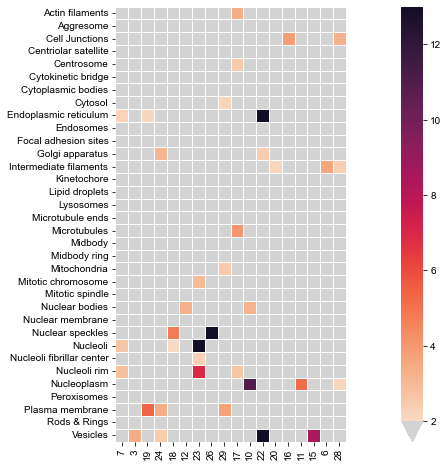

In [10]:
import matplotlib as mpl
import seaborn as sbn
import math

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')


pvalsbylocationlog2=tmp
pvalsbylocationlog2[:] = pvalsbylocationlog2[:, myclustorder]
print(pvalsbylocationlog2)

mymask=np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0);
print(np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0))
#print(pvalsbylocation[:,mymask])

mysubfeats=[]
for i in range(0,len(mymask)):
    if mymask[i] == True:
        mysubfeats.append(myclustorder[i])


c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (20, 8)) 
sbn.heatmap(pvalsbylocationlog2[:,mymask],cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=.5)
plt.yticks(np.arange(0.5, len(uniqueloc), 1), uniqueloc,rotation=0) 
plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=90) 

plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"
#plt.savefig("Figures/2024_02/fisher_exact_test_pvals_location_heatmap_by_cluster_median_sorted_all_human_gte_65_and_nonlinkers_gte_50_idrs.pdf", transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_location_heatmap_by_cluster_median_sorted_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.pdf', transparent=True, bbox_inches = "tight") 


tmpidx=uniqueloc.index('Nucleoli')
print(pvalsbylocationlog2[tmpidx,:])

tmpidx=uniqueloc.index('Nuclear speckles')
print(pvalsbylocationlog2[tmpidx,:])

tmpidx=uniqueloc.index('Nucleoplasm')
print(pvalsbylocationlog2[tmpidx,:])

## 2.8b - Plot p-values by sorted clusters bubble plot

hi
[ 0.05616491 -0.          3.28021215  1.27627996  0.21787715 -0.
 -0.          0.01666918  0.06470013 -0.          0.18405036  0.05804941
  2.35083439 -0.         -0.         -0.         -0.         -0.
  0.57864721 -0.          0.12182899 -0.          0.50286594  0.01005202
  0.28303341  0.90252825  0.11250341  1.21879653  0.03569407  2.1549287
 -0.          0.16802275 -0.          0.01578871]
[0.47363339        nan 3.63432836 2.99789474 0.9876161  0.
 0.         0.68646081 0.57350272 0.         0.95380273 0.6529819
 5.13183126 0.         0.         0.         0.         0.
 3.51470588 0.         0.75857917 0.         2.81045752 0.34729037
 1.09703426 1.53248693 0.81782499 2.25853485 0.3920952  1.51703175
 0.         0.90805417 0.         0.56887903]


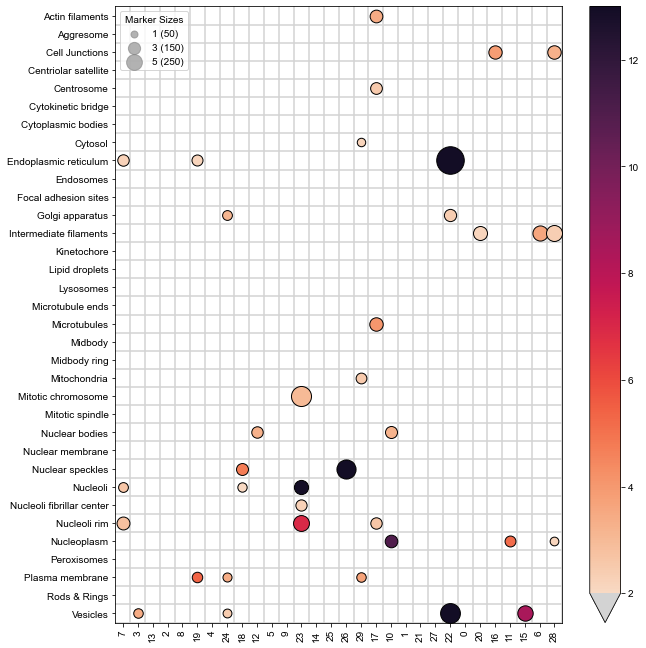

In [135]:
myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
pvalsbylocationlog2=tmp
pvalsbylocationlog2[:] = pvalsbylocationlog2[:, myclustorder]
#print(pvalsbylocationlog2)

tmp=np.loadtxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt')
oddsratiobylocation2=tmp
oddsratiobylocation2[:] = oddsratiobylocation2[:, myclustorder]

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

szscale=50
fig, ax = plt.subplots(figsize=(len(myclustorder)/3,len(uniqueloc)/3))
for a in range(0,len(uniqueloc)):
    ax.plot([-0.5,len(myclustorder)],[-1*a-0.5,-1*a-0.5],'-',color='lightgrey',zorder=0)
    for c in range(0,numkclusts):
        if a==0:
            ax.plot([c+0.5,c+0.5],[0.5,-1*(len(uniqueloc))],'-',color='lightgrey',zorder=0)
        if pvalsbylocationlog2[a,c] > -math.log10(0.01):
            #plt.scatter(c,-1*a,s=pvalsbylocationlog2[a,c]*30,c=oddsratiobylocation2[a,c],cmap='Spectral',vmin=0,vmax=5,edgecolor='black',zorder=1)
            myscatter=ax.scatter(c,-1*a,s=oddsratiobylocation2[a,c]*szscale,c=pvalsbylocationlog2[a,c],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=1)

        
plt.colorbar(myscatter,extend='min',ax=ax)
ax.set_yticks(np.arange(0, -1*(len(uniqueloc)), -1), uniqueloc,rotation=0) 
ax.set_xticks(np.arange(0, len(myclustorder), 1), myclustorder,rotation=90) 
ax.set_ylim([-1*(len(uniqueloc))+0.5,0.5])
ax.set_xlim([-0.5,len(myclustorder)-0.5])
#plt.grid(zorder=0)
print('hi')

size_val=1*np.array([1,3,5])

for size_val, label_text in [(szscale, "1"), (szscale*3, "3"), (szscale*5, "5")]:
    ax.scatter([], [], s=size_val, color='gray', alpha=0.6, label=f'{label_text} ({size_val})')

plt.legend(scatterpoints=1, frameon=True, title="Marker Sizes")

#kw = dict(prop="sizes", num=5, fmt="{x:.0f}", func=lambda s: s*50)
#legend2 = ax.legend(*myscatter.legend_elements(**kw), loc="upper right", title="Sizes")

#handles, labels = myscatter.legend_elements(prop="sizes")
#legend2 = ax.legend(handles, labels, loc="upper right", title="Circle Size")


#print(np.max(oddsratiobylocation2,axis=1))

print(pvalsbylocationlog2[:,29])
print(oddsratiobylocation2[:,29])

## 2.9 - Get number of IDRs by location

In [136]:
numIDRsbyloc=[]
for a in range(0,len(uniqueloc)):
    print(uniqueloc[a])
    print(len(uniquelocacc[a]))
    sumallidrs=0
    for s in range(0,len(subaccs)):
        if subaccs[s] in mappedaccs:
            if subaccs[s] in uniquelocacc[a]:
                sumallidrs=sumallidrs+1
    numIDRsbyloc.append(sumallidrs)
    print(sumallidrs)
    
print(numIDRsbyloc)

Actin filaments
136
89
Aggresome
4
0
Cell Junctions
192
145
Centriolar satellite
92
61
Centrosome
208
87
Cytokinetic bridge
25
19
Cytoplasmic bodies
43
19
Cytosol
2961
1285
Endoplasmic reticulum
456
147
Endosomes
16
6
Focal adhesion sites
88
45
Golgi apparatus
828
321
Intermediate filaments
109
47
Kinetochore
2
5
Lipid droplets
27
5
Lysosomes
17
5
Microtubule ends
4
10
Microtubules
195
87
Midbody
21
13
Midbody ring
4
4
Mitochondria
967
168
Mitotic chromosome
27
19
Mitotic spindle
18
16
Nuclear bodies
316
238
Nuclear membrane
185
118
Nuclear speckles
398
320
Nucleoli
847
516
Nucleoli fibrillar center
194
120
Nucleoli rim
129
107
Nucleoplasm
4781
3200
Peroxisomes
22
5
Plasma membrane
1532
748
Rods & Rings
5
1
Vesicles
1555
576
[89, 0, 145, 61, 87, 19, 19, 1285, 147, 6, 45, 321, 47, 5, 5, 5, 10, 87, 13, 4, 168, 19, 16, 238, 118, 320, 516, 120, 107, 3200, 5, 748, 1, 576]


## 2.10 - Plot p-values by sorted clusters and sorted rows by IDR enrichment

                     Location  Number of IDRs          IDRs         7  \
29                Nucleoplasm            3200  6.046537e+01  0.320972   
25           Nuclear speckles             320  8.098650e+00  0.106511   
26                   Nucleoli             516  6.543247e+00  2.629869   
28               Nucleoli rim             107  6.535094e+00  2.776766   
23             Nuclear bodies             238  3.402037e+00  0.123000   
0             Actin filaments              89  2.226644e+00  0.026714   
2              Cell Junctions             145  2.171919e+00  0.004330   
3        Centriolar satellite              61  1.913969e+00  0.068255   
27  Nucleoli fibrillar center             120  1.552406e+00  1.491587   
10       Focal adhesion sites              45  1.031792e+00 -0.000000   
24           Nuclear membrane             118  5.849238e-01  0.301286   
12     Intermediate filaments              47  8.174687e-02 -0.000000   
4                  Centrosome              87  3.97

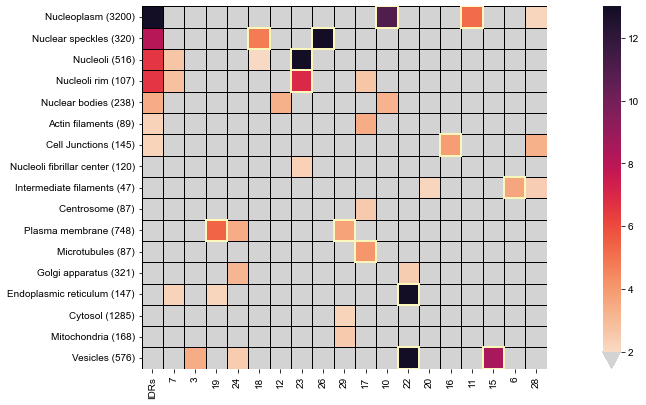

In [137]:
numkclusts=max(subclusters)+1
minIDRnum=25

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
tmp2=np.loadtxt('data/subcellular_location_HPA_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt')

# Create data frame of locations, number of IDRs, enrichment of IDRs, cluster enrichment 
dfenrichloc=pd.DataFrame()
dfenrichloc['Location']=uniqueloc
dfenrichloc['Number of IDRs']=numIDRsbyloc
dfenrichloc['IDRs']=tmp2
#print(dfenrichloc)

for i in range(0,len(myclustorder)):
    dfenrichloc[myclustorder[i]]=tmp[:,myclustorder[i]]
    
# Only keep locations if have at least minIDRnum
dfenrichloc=dfenrichloc[dfenrichloc['Number of IDRs']>=minIDRnum]

# Sort by enrichment in proteins having IDRs
dfenrichloc=dfenrichloc.sort_values(by=['IDRs','Number of IDRs'],ascending=False)
print(dfenrichloc)

# Convert data to numpy array
allcolumns=dfenrichloc.columns.values.tolist()
datacolumns=allcolumns[2:]
tmppvalsbylocationlog=dfenrichloc[datacolumns].to_numpy()
print(np.shape(tmppvalsbylocationlog))

# Get names for plotting
sortedlocnamesnonums=dfenrichloc['Location'].tolist()
sortedidrnums=dfenrichloc['Number of IDRs'].tolist()
sortedlocnames=[]
for i in range(0,len(sortedlocnamesnonums)):
    sortedlocnames.append(sortedlocnamesnonums[i]+' ('+str(sortedidrnums[i])+')')


pvalsbylocationlog2=tmppvalsbylocationlog
print(pvalsbylocationlog2)

mymask=np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0);
mymask2=np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=1);
print(np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0))
#print(pvalsbylocation[:,mymask])

mysubfeats=[]
for i in range(0,len(mymask)):
    if mymask[i] == True:
        mysubfeats.append(datacolumns[i])

mysublocnames=[]
for i in range(0,len(mymask2)):
    if mymask2[i] == True:
        mysublocnames.append(sortedlocnames[i])
        
c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (20, len(sortedlocnames)/3)) 
tmp=pvalsbylocationlog2[:,mymask]
maskedvals=tmp[mymask2,:]
sbn.heatmap(maskedvals,cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=.5,linecolor='#000000')
plt.yticks(np.arange(0.5, len(mysublocnames), 1), mysublocnames,rotation=0) 
plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=90) 

# If want to account for multiple hypothesis correction using Bonferroni correction across the 30 clusters
for i in range(0,len(maskedvals)):
    for j in range(1,len(maskedvals[0])):
        if maskedvals[i][j]> -math.log10(0.01/len(myclustorder)):
            ax.add_patch(patches.Rectangle((j, i),1,1,edgecolor='#fbf6b9',fill=False,lw=2))
print(len(myclustorder))    

#plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_04//fisher_exact_test_pvals_location_heatmap_by_cluster_median_sorted_by_IDR_enrichment_if_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs_30_clusters_correction.pdf', transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_location_heatmap_by_cluster_median_sorted_by_IDR_enrichment_if_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs.pdf', transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_location_heatmap_by_cluster_median_sorted_by_IDR_enrichment_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs.pdf', transparent=True, bbox_inches = "tight") 

## 2.10b as bubble plot

Nuclear speckles 26
365.76417004048585
Nucleoli rim 23
252.50042560435818
Endoplasmic reticulum 22
758.3366180528183
Vesicles 22
392.02614379084963
50
150
250


meta NOT subset; don't know how to subset; dropped


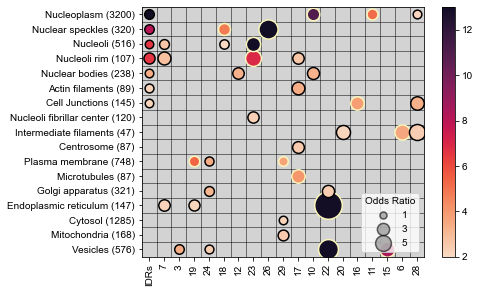

In [219]:
numkclusts=max(subclusters)+1
minIDRnum=25

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
tmp2=np.loadtxt('data/subcellular_location_HPA_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt')
tmpor=np.loadtxt('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt')
tmpor2=np.loadtxt('data/subcellular_location_HPA_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_odds_ratio.txt')

# Create data frame of locations, number of IDRs, enrichment of IDRs, cluster enrichment 
dfenrichloc=pd.DataFrame()
dfenrichloc['Location']=uniqueloc
dfenrichloc['Number of IDRs']=numIDRsbyloc
dfenrichloc['IDRs']=tmp2
dfenrichloc['IDRs Odds Ratio']=tmpor2
#print(dfenrichloc)

for i in range(0,len(myclustorder)):
    dfenrichloc[myclustorder[i]]=tmp[:,myclustorder[i]]
    dfenrichloc[str(myclustorder[i])+' Odds Ratio']=tmpor[:,myclustorder[i]]
    
# Only keep locations if have at least minIDRnum
dfenrichloc=dfenrichloc[dfenrichloc['Number of IDRs']>=minIDRnum]

# Sort by enrichment in proteins having IDRs
dfenrichloc=dfenrichloc.sort_values(by=['IDRs','Number of IDRs'],ascending=False)
#print(dfenrichloc) 
#print(dfenrichloc[['IDRs']+myclustorder]) 


# Remove Clusters that have no significant enrichment 
nonsigclustnum=0
sigclustlist=[]
cols_to_drop = []
for col in myclustorder:
    if (dfenrichloc[col] <= -math.log10(0.01)).all(): # Check if ALL values in the column are less than x
        cols_to_drop.append(col)
        cols_to_drop.append(str(col)+' Odds Ratio')
        nonsigclustnum=nonsigclustnum+1
    else:
        sigclustlist.append(col)
        
# Remove loactions that have no significant enrichment
condition = (dfenrichloc[['IDRs']+myclustorder] <= -math.log10(0.01)).all(axis=1)

# Filter the DataFrame to keep rows where the condition is NOT met
dfenrichloc = dfenrichloc[~condition]
        
dfenrichloc = dfenrichloc.drop(columns=cols_to_drop)
enrichloclist=dfenrichloc['Location'].tolist()
#print(dfenrichloc) 
#print(sigclustlist)
#hi

# Get names for plotting
sortedlocnamesnonums=dfenrichloc['Location'].tolist()
sortedidrnums=dfenrichloc['Number of IDRs'].tolist()
sortedlocnames=[]
for i in range(0,len(sortedlocnamesnonums)):
    sortedlocnames.append(sortedlocnamesnonums[i]+' ('+str(sortedidrnums[i])+')')


c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

szscale=50
fig, ax = plt.subplots(figsize=((len(sigclustlist)+1)/3,len(enrichloclist)/3.7))
ax.set_facecolor('lightgrey')
for a in range(0,len(enrichloclist)):
    ax.plot([-0.5,len(sigclustlist)-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=-1,linewidth=0.5)
    ax.plot([-1.5,-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=0,linewidth=0.5)
    for c in range(-1,len(sigclustlist)):
        if a==0:
            ax.plot([c+0.5,c+0.5],[0.5,-1*(len(enrichloclist))+0.5],'-',color='black',zorder=0,linewidth=0.5)
            
        # Plot enrichment of IDRs in a location
        if c==-1:
            if dfenrichloc['IDRs'].tolist()[a] > -math.log10(0.01): 
                if dfenrichloc['IDRs Odds Ratio'].tolist()[a]>5:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichloc['IDRs Odds Ratio'].tolist()[a]*szscale,c=dfenrichloc['IDRs'].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=1,linewidths=1.5)
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichloc['IDRs Odds Ratio'].tolist()[a]*szscale,c=dfenrichloc['IDRs'].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=2,linewidths=1.5)                    

        # Plot enrichment of IDRs of a given cluster in a location
        else:
            if dfenrichloc[sigclustlist[c]].tolist()[a] > -math.log10(0.01):
                if dfenrichloc[sigclustlist[c]].tolist()[a] > -math.log10(0.01/len(myclustorder)):
                    if dfenrichloc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>5:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichloc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichloc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=1,linewidths=1.5)
                        print(enrichloclist[a]+' '+str(sigclustlist[c]))
                        print(dfenrichloc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale)
                    else:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichloc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichloc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=2,linewidths=1.5)                    
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichloc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichloc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=2,linewidths=1.5)

        
#plt.colorbar(myscatter,extend='min',ax=ax)
plt.colorbar(myscatter,ax=ax)
ax.set_yticks(np.arange(0, -1*(len(sortedlocnames)), -1), sortedlocnames,rotation=0) 
ax.set_xticks(np.arange(-1, len(sigclustlist), 1), ['IDRs']+sigclustlist,rotation=90) 
ax.set_ylim([-1*(len(enrichloclist))+0.5,0.5])
ax.set_xlim([-1.5,len(sigclustlist)-0.5])

size_val_arr=np.array([1,3,5])
for size_val, label_text in [(szscale*size_val_arr[0], "1"), (szscale*size_val_arr[1], "3"), (szscale*size_val_arr[2], "5")]:
    ax.scatter([], [], s=size_val, color='gray', edgecolor='black',linewidth=1.5, alpha=0.6, label=f'{label_text}')
    print(size_val)
plt.legend(scatterpoints=1, frameon=True, title="Odds Ratio")

#plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_08//fisher_exact_test_pvals_location_heatmap_by_cluster_median_sorted_by_IDR_enrichment_if_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs_30_clusters_correction_bubble.pdf', transparent=True, bbox_inches = "tight") 


In [225]:
dfenrichloc[['Location',29,'29 Odds Ratio']]

,Location,29,29 Odds Ratio
29,Nucleoplasm,0.000717,0.707449
25,Nuclear speckles,0.009561,0.535167
26,Nucleoli,0.005334,0.575669
28,Nucleoli rim,0.019444,0.402851
23,Nuclear bodies,0.127612,0.834502
0,Actin filaments,0.039347,0.487607
2,Cell Junctions,1.897768,2.154487
27,Nucleoli fibrillar center,0.001707,0.176727
12,Intermediate filaments,0.053332,0.462564
4,Centrosome,0.457089,1.307728


## 2.11 - Add data to excel file

In [13]:
locdf=pd.DataFrame()
locdf['Location']=mysublocnames
for i in range(0,len(mysubfeats)):
    locdf[mysubfeats[i]]=maskedvals[:,i]
    
print(locdf)

#with pd.ExcelWriter('../Supplementary_Tables/Table_S1.xlsx', engine='openpyxl',mode='a') as writer:
#    locdf.to_excel(writer,sheet_name='Fig_1F')

#dfenrichloc.to_excel('data/')

                           Location          IDRs         7         3  \
0                Nucleoplasm (3200)  6.046537e+01  0.320972  0.002646   
1            Nuclear speckles (320)  8.098650e+00  0.106511  0.091260   
2                    Nucleoli (516)  6.543247e+00  2.629869  0.968704   
3                Nucleoli rim (107)  6.535094e+00  2.776766  0.042773   
4              Nuclear bodies (238)  3.402037e+00  0.123000  0.019768   
5              Actin filaments (89)  2.226644e+00  0.026714  0.004593   
6              Cell Junctions (145)  2.171919e+00  0.004330  0.366745   
7   Nucleoli fibrillar center (120)  1.552406e+00  1.491587  0.853903   
8       Intermediate filaments (47)  8.174687e-02 -0.000000  0.041419   
9                   Centrosome (87)  3.973735e-02  1.282355  0.089805   
10            Plasma membrane (748)  1.143033e-02  0.000051  1.630673   
11                Microtubules (87)  8.953304e-03  0.293447  0.582728   
12            Golgi apparatus (321)  7.844258e-07  

In [46]:
tmpdf=pd.read_excel('../Supplementary_Tables/Table_S1.xlsx',sheet_name='Fig_1F')

print(tmpdf)

    Unnamed: 0                         Location          IDRs         7  \
0            0               Nucleoplasm (3200)  6.046537e+01  0.320972   
1            1           Nuclear speckles (320)  8.098650e+00  0.106511   
2            2                   Nucleoli (516)  6.543247e+00  2.629869   
3            3               Nucleoli rim (107)  6.535094e+00  2.776766   
4            4             Nuclear bodies (238)  3.402037e+00  0.123000   
5            5             Actin filaments (89)  2.226644e+00  0.026714   
6            6             Cell Junctions (145)  2.171919e+00  0.004330   
7            7  Nucleoli fibrillar center (120)  1.552406e+00  1.491587   
8            8      Intermediate filaments (47)  8.174687e-02  0.000000   
9            9                  Centrosome (87)  3.973735e-02  1.282355   
10          10            Plasma membrane (748)  1.143033e-02  0.000051   
11          11                Microtubules (87)  8.953304e-03  0.293447   
12          12           

In [227]:
print(dfenrichloc)
#dfenrichloc.to_excel('data/subcellular_location_HPA_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.xlsx')

                     Location  Number of IDRs          IDRs  IDRs Odds Ratio  \
29                Nucleoplasm            3200  6.046537e+01         1.857074   
25           Nuclear speckles             320  8.098650e+00         1.793283   
26                   Nucleoli             516  6.543247e+00         1.437728   
28               Nucleoli rim             107  6.535094e+00         2.471779   
23             Nuclear bodies             238  3.402037e+00         1.481070   
0             Actin filaments              89  2.226644e+00         1.570865   
2              Cell Junctions             145  2.171919e+00         1.453059   
27  Nucleoli fibrillar center             120  1.552406e+00         1.337448   
12     Intermediate filaments              47  8.174687e-02         0.840778   
4                  Centrosome              87  3.973735e-02         0.826812   
31            Plasma membrane             748  1.143033e-02         0.896775   
17               Microtubules           

# Part 3: Get enrichment of Molecular Function by Cluster

## 3.1 - Load in GO information from https://go.princeton.edu/cgi-bin/GOTermMapper

In [228]:
GOtable=pd.read_table('../general_data/GO_Terms/GO_Function_Slim.txt')

print(GOtable)

          GOID                                              TERM  \
0   GO:0003824                                catalytic activity   
1   GO:0003677                                       DNA binding   
2   GO:0016787                                hydrolase activity   
3   GO:0140096           catalytic activity, acting on a protein   
4   GO:0016740                              transferase activity   
5   GO:0098772             molecular function regulator activity   
6   GO:0140110                  transcription regulator activity   
7   GO:0003723                                       RNA binding   
8   GO:0060089                     molecular transducer activity   
9   GO:0005215                              transporter activity   
10  GO:0008092                      cytoskeletal protein binding   
11  GO:0008289                                     lipid binding   
12  GO:0005198                      structural molecule activity   
13  GO:0016491                           oxidore

## 3.2 - Get all unique molecular functions

In [229]:
allgo=GOtable['GOID'].tolist()
allterm=GOtable['TERM'].tolist()
allgenegroups=GOtable['ANNOTATED_GENES'].tolist()
allmolfunctionterm=allterm

print(allterm)
print(len(allgenegroups[1]))
print(len(allgenegroups))
print(allgenegroups[1])

['catalytic activity', 'DNA binding', 'hydrolase activity', 'catalytic activity, acting on a protein', 'transferase activity', 'molecular function regulator activity', 'transcription regulator activity', 'RNA binding', 'molecular transducer activity', 'transporter activity', 'cytoskeletal protein binding', 'lipid binding', 'structural molecule activity', 'oxidoreductase activity', 'molecular adaptor activity', 'ATP-dependent activity', 'receptor ligand activity', 'catalytic activity, acting on RNA', 'GTPase activity', 'catalytic activity, acting on DNA', 'histone binding', 'lyase activity', 'ligase activity', 'isomerase activity', 'translation regulator activity', 'cytoskeletal motor activity', 'molecular carrier activity', 'cargo receptor activity', 'antioxidant activity', 'virus receptor activity', 'protein folding chaperone', 'cell adhesion mediator activity', 'general transcription initiation factor activity', 'small molecule sensor activity', 'molecular sequestering activity', 'cy

## 3.3 - Get mapped accessions

In [230]:
# Load in mapping of accessions to ensemble

allgoacc=[]
eachgoacc=[]
for g in allgenegroups:
    tmp=g.split(',')
    tmpacc=[]
    for i in tmp:
        tmpacc.append(i.strip())
        allgoacc.append(i.strip())
    eachgoacc.append(tmpacc)

print(len(eachgoacc))

mappedaccs=[]
for f in range(0,len(accs_all_human)):
    if accs_all_human[f] in allgoacc:
        mappedaccs.append(accs_all_human[f])
            

print(len(accs_all_human))
print('Number of mapped accessions '+str(len(mappedaccs)))

40
20882
Number of mapped accessions 14016


## 3.4 - Get molecular function enrichment in IDRs

In [231]:
pvalsbylocation=np.zeros((len(eachgoacc)))
pvalsbylocationlog=np.zeros((len(eachgoacc)))
oddsratiobylocation=np.zeros((len(eachgoacc)))

for a in range(0,len(eachgoacc)):
    print(allmolfunctionterm[a])
    sumallidrs=0
    
    # For each function determine if IDRs are enriched there
    subfeatureyes=0
    subfeatureno=0
    restfeatureyes=0
    restfeatureno=0
    
    for s in range(0,len(accs_all_human)):
        if accs_all_human[s] in mappedaccs:
            if accs_all_human[s] in eachgoacc[a]: # if in function
                if accs_all_human[s] in subaccsNODIST: # if houses IDR
                        subfeatureyes=subfeatureyes+1
                        sumallidrs=sumallidrs+1
                else:
                    subfeatureno=subfeatureno+1
            else:
                if accs_all_human[s] in subaccsNODIST:
                    restfeatureyes=restfeatureyes+1
                else:
                    restfeatureno=restfeatureno+1
                
    print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

    # defining the table
    if subfeatureyes+restfeatureyes>0:
        data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
        print(data)
        # One-sided greater used to test if greater occurrence in nucleolus
        res = fisher_exact(data, alternative='greater')
        print(res[1])
        pvalsbylocation[a]=res[1]
        pvalsbylocationlog[a]=-math.log10(res[1])
        oddsratiobylocation[a]=res[0]
            
    print('Number of IDRs in '+allmolfunctionterm[a]+' '+str(subfeatureyes+subfeatureno))
    print(sumallidrs)

print(pvalsbylocation)

catalytic activity
14016
[[1278, 4331], [3060, 5347]]
0.9999999999862398
Number of IDRs in catalytic activity 5609
1278
DNA binding
14016
[[1293, 1203], [3045, 8475]]
2.7940143673452227e-128
Number of IDRs in DNA binding 2496
1293
hydrolase activity
14016
[[556, 1867], [3782, 7811]]
1.0
Number of IDRs in hydrolase activity 2423
556
catalytic activity, acting on a protein
14016
[[746, 1555], [3592, 8123]]
0.05043213382924443
Number of IDRs in catalytic activity, acting on a protein 2301
746
transferase activity
14016
[[622, 1657], [3716, 8021]]
0.9999860392078177
Number of IDRs in transferase activity 2279
622
molecular function regulator activity
14016
[[611, 1413], [3727, 8265]]
0.7960446562446132
Number of IDRs in molecular function regulator activity 2024
611
transcription regulator activity
14016
[[997, 897], [3341, 8781]]
9.20028158503178e-100
Number of IDRs in transcription regulator activity 1894
997
RNA binding
14016
[[781, 874], [3557, 8804]]
1.8928398152472985e-49
Number of I

## 3.5 - Save p-values

In [232]:
#np.savetxt('data/molecular_function_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt', pvalsbylocationlog)
#np.savetxt('data/molecular_function_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_odds_ratio.txt', oddsratiobylocation)

## 3.6 - Get molecular function enrichment by cluster

In [240]:
numkclusts=max(subclusters)+1

pvalsbylocation=np.zeros((len(eachgoacc),numkclusts))
pvalsbylocationlog=np.zeros((len(eachgoacc),numkclusts))
oddsratiobylocation=np.zeros((len(eachgoacc),numkclusts))

for a in range(0,len(eachgoacc)):
    for c in range(0,numkclusts):
        print(allterm[a])
        print('Cluster_'+str(c))
        midx = [i for i, x in enumerate(subclusters) if x == c]
        
        topaccs=[]
        for i in midx:
            topaccs.append(subaccswnums[i])
        
        #print(topaccs)
    
        # For each location determine if that feature is enriched there
        subfeatureyes=0
        subfeatureno=0
        restfeatureyes=0
        restfeatureno=0
        for s in range(0,len(subaccs)):
            if subaccs[s] in mappedaccs:
                if subaccs[s] in eachgoacc[a]:
                    if subaccswnums[s] in topaccs:
                        subfeatureyes=subfeatureyes+1
                    else:
                        subfeatureno=subfeatureno+1
                else:
                    if subaccswnums[s] in topaccs:
                        restfeatureyes=restfeatureyes+1
                    else:
                        restfeatureno=restfeatureno+1

        print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

        # defining the table
        if subfeatureyes+restfeatureyes>0:
            data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
            print(data)
            # One-sided greater used to test if greater occurrence in nucleolus
            res = fisher_exact(data, alternative='greater')
            print(res[1])
            pvalsbylocation[a,c]=res[1]
            pvalsbylocationlog[a,c]=-math.log10(res[1])
            oddsratiobylocation[a,c]=res[0]
            
    print('Number of IDRs in '+allterm[a]+' '+str(subfeatureyes+subfeatureno))

print(pvalsbylocation)


catalytic activity
Cluster_0
5955
[[48, 1638], [138, 4131]]
0.8024244377153373
catalytic activity
Cluster_1
5955
[[53, 1633], [169, 4100]]
0.9439403966189731
catalytic activity
Cluster_2
5955
[[15, 1671], [62, 4207]]
0.9722037356347304
catalytic activity
Cluster_3
5955
[[81, 1605], [190, 4079]]
0.2989921854379464
catalytic activity
Cluster_4
5955
[[79, 1607], [143, 4126]]
0.009774723644433474
catalytic activity
Cluster_5
5955
[[42, 1644], [82, 4187]]
0.10030513982393535
catalytic activity
Cluster_6
5955
[[90, 1596], [261, 4008]]
0.8868754869511414
catalytic activity
Cluster_7
5955
[[51, 1635], [144, 4125]]
0.7752867966454609
catalytic activity
Cluster_8
5955
[[20, 1666], [69, 4200]]
0.9142006473998114
catalytic activity
Cluster_9
5955
[[89, 1597], [180, 4089]]
0.04519949757686398
catalytic activity
Cluster_10
5955
[[43, 1643], [107, 4162]]
0.49265014714002103
catalytic activity
Cluster_11
5955
[[34, 1652], [89, 4180]]
0.6004505050255066
catalytic activity
Cluster_12
5955
[[65, 1621], [

5955
[[17, 1009], [106, 4823]]
0.8730748585446806
catalytic activity, acting on a protein
Cluster_12
5955
[[37, 989], [149, 4780]]
0.18849223561455383
catalytic activity, acting on a protein
Cluster_13
5955
[[46, 980], [181, 4748]]
0.1270619636110765
catalytic activity, acting on a protein
Cluster_14
5955
[[38, 988], [154, 4775]]
0.19377295114161613
catalytic activity, acting on a protein
Cluster_15
5955
[[10, 1016], [75, 4854]]
0.9376801714841837
catalytic activity, acting on a protein
Cluster_16
5955
[[38, 988], [135, 4794]]
0.061151354627111756
catalytic activity, acting on a protein
Cluster_17
5955
[[55, 971], [234, 4695]]
0.22403990979744964
catalytic activity, acting on a protein
Cluster_18
5955
[[28, 998], [156, 4773]]
0.795901568480064
catalytic activity, acting on a protein
Cluster_19
5955
[[23, 1003], [181, 4748]]
0.9937344349265186
catalytic activity, acting on a protein
Cluster_20
5955
[[43, 983], [181, 4748]]
0.2377007510573714
catalytic activity, acting on a protein
Clust

5955
[[38, 1418], [231, 4268]]
0.9999927668281072
transcription regulator activity
Cluster_10
5955
[[77, 1379], [73, 4426]]
6.017603337867348e-13
transcription regulator activity
Cluster_11
5955
[[60, 1396], [63, 4436]]
3.0648608511858457e-09
transcription regulator activity
Cluster_12
5955
[[60, 1396], [126, 4373]]
0.008828384522614946
transcription regulator activity
Cluster_13
5955
[[49, 1407], [178, 4321]]
0.8655437663039053
transcription regulator activity
Cluster_14
5955
[[50, 1406], [142, 4357]]
0.3273895876919685
transcription regulator activity
Cluster_15
5955
[[16, 1440], [69, 4430]]
0.9135818156237517
transcription regulator activity
Cluster_16
5955
[[36, 1420], [137, 4362]]
0.8903851085162268
transcription regulator activity
Cluster_17
5955
[[52, 1404], [237, 4262]]
0.9971755177697631
transcription regulator activity
Cluster_18
5955
[[38, 1418], [146, 4353]]
0.9058831149311276
transcription regulator activity
Cluster_19
5955
[[42, 1414], [162, 4337]]
0.9196275975661511
tran

5955
[[6, 283], [167, 5499]]
0.8528279566723704
transporter activity
Cluster_17
5955
[[11, 278], [278, 5388]]
0.8390453732618558
transporter activity
Cluster_18
5955
[[7, 282], [177, 5489]]
0.7977537521503397
transporter activity
Cluster_19
5955
[[12, 277], [192, 5474]]
0.2864727693585639
transporter activity
Cluster_20
5955
[[11, 278], [213, 5453]]
0.5291851926782611
transporter activity
Cluster_21
5955
[[8, 281], [97, 5569]]
0.13648533151483996
transporter activity
Cluster_22
5955
[[1, 288], [94, 5572]]
0.99147459687861
transporter activity
Cluster_23
5955
[[10, 279], [238, 5428]]
0.7728052990033083
transporter activity
Cluster_24
5955
[[12, 277], [330, 5336]]
0.9120767104484682
transporter activity
Cluster_25
5955
[[20, 269], [237, 5429]]
0.023957126630636802
transporter activity
Cluster_26
5955
[[5, 284], [127, 5539]]
0.775642546472957
transporter activity
Cluster_27
5955
[[16, 273], [279, 5387]]
0.3585506099233278
transporter activity
Cluster_28
5955
[[4, 285], [155, 5511]]
0.9546

5955
[[23, 381], [319, 5232]]
0.5507605591247806
structural molecule activity
Cluster_25
5955
[[9, 395], [248, 5303]]
0.9929091860544559
structural molecule activity
Cluster_26
5955
[[5, 399], [127, 5424]]
0.9511077074854207
structural molecule activity
Cluster_27
5955
[[17, 387], [278, 5273]]
0.7954033268342078
structural molecule activity
Cluster_28
5955
[[19, 385], [140, 5411]]
0.010772879255911583
structural molecule activity
Cluster_29
5955
[[13, 391], [266, 5285]]
0.9479188779480817
Number of IDRs in structural molecule activity 404
oxidoreductase activity
Cluster_0
5955
[[2, 83], [184, 5686]]
0.7501226730811887
oxidoreductase activity
Cluster_1
5955
[[5, 80], [217, 5653]]
0.20988667049868107
oxidoreductase activity
Cluster_2
5955
[[0, 85], [77, 5793]]
1.0
oxidoreductase activity
Cluster_3
5955
[[5, 80], [266, 5604]]
0.34452818758053505
oxidoreductase activity
Cluster_4
5955
[[3, 82], [219, 5651]]
0.6199797854303672
oxidoreductase activity
Cluster_5
5955
[[6, 79], [118, 5752]]
0.

...

5955
[[1, 24], [270, 5660]]
0.6886409339218931
isomerase activity
Cluster_4
5955
[[1, 24], [221, 5709]]
0.6139400008799697
isomerase activity
Cluster_5
5955
[[0, 25], [124, 5806]]
1.0
isomerase activity
Cluster_6
5955
[[1, 24], [350, 5580]]
0.7817095294049987
isomerase activity
Cluster_7
5955
[[1, 24], [194, 5736]]
0.5657146507004356
isomerase activity
Cluster_8
5955
[[0, 25], [89, 5841]]
1.0
isomerase activity
Cluster_9
5955
[[0, 25], [269, 5661]]
1.0
isomerase activity
Cluster_10
5955
[[0, 25], [150, 5780]]
1.0
isomerase activity
Cluster_11
5955
[[0, 25], [123, 5807]]
1.0
isomerase activity
Cluster_12
5955
[[1, 24], [185, 5745]]
0.5483916583990537
isomerase activity
Cluster_13
5955
[[3, 22], [224, 5706]]
0.06785358163570676
isomerase activity
Cluster_14
5955
[[1, 24], [191, 5739]]
0.5600124468026293
isomerase activity
Cluster_15
5955
[[0, 25], [85, 5845]]
1.0
isomerase activity
Cluster_16
5955
[[1, 24], [172, 5758]]
0.5221940143976529
isomerase activity
Cluster_17
5955
[[0, 25], [289

5955
[[2, 21], [83, 5849]]
0.04196340607386044
molecular carrier activity
Cluster_16
5955
[[0, 23], [173, 5759]]
1.0
molecular carrier activity
Cluster_17
5955
[[1, 22], [288, 5644]]
0.6822124024877227
molecular carrier activity
Cluster_18
5955
[[2, 21], [182, 5750]]
0.1576626761552652
molecular carrier activity
Cluster_19
5955
[[1, 22], [203, 5729]]
0.5521210432967418
molecular carrier activity
Cluster_20
5955
[[2, 21], [222, 5710]]
0.21366878005145684
molecular carrier activity
Cluster_21
5955
[[1, 22], [104, 5828]]
0.3362992815466303
molecular carrier activity
Cluster_22
5955
[[0, 23], [95, 5837]]
1.0
molecular carrier activity
Cluster_23
5955
[[0, 23], [248, 5684]]
1.0
molecular carrier activity
Cluster_24
5955
[[0, 23], [342, 5590]]
1.0
molecular carrier activity
Cluster_25
5955
[[0, 23], [257, 5675]]
1.0
molecular carrier activity
Cluster_26
5955
[[0, 23], [132, 5800]]
1.0
molecular carrier activity
Cluster_27
5955
[[1, 22], [294, 5638]]
0.6898776008629695
molecular carrier activ

5955
[[7, 19], [188, 5741]]
1.4048923746978193e-05
protein folding chaperone
Cluster_8
5955
[[0, 26], [89, 5840]]
1.0
protein folding chaperone
Cluster_9
5955
[[0, 26], [269, 5660]]
1.0
protein folding chaperone
Cluster_10
5955
[[0, 26], [150, 5779]]
1.0
protein folding chaperone
Cluster_11
5955
[[1, 25], [122, 5807]]
0.4194653436422852
protein folding chaperone
Cluster_12
5955
[[0, 26], [186, 5743]]
1.0
protein folding chaperone
Cluster_13
5955
[[1, 25], [226, 5703]]
0.6367461070173989
protein folding chaperone
Cluster_14
5955
[[0, 26], [192, 5737]]
1.0
protein folding chaperone
Cluster_15
5955
[[0, 26], [85, 5844]]
1.0
protein folding chaperone
Cluster_16
5955
[[1, 25], [172, 5757]]
0.5361333795751182
protein folding chaperone
Cluster_17
5955
[[0, 26], [289, 5640]]
1.0
protein folding chaperone
Cluster_18
5955
[[0, 26], [184, 5745]]
1.0
protein folding chaperone
Cluster_19
5955
[[5, 21], [199, 5730]]
0.0016412498006306289
protein folding chaperone
Cluster_20
5955
[[0, 26], [224, 5705

5955
[[0, 17], [150, 5788]]
1.0
small molecule sensor activity
Cluster_11
5955
[[0, 17], [123, 5815]]
1.0
small molecule sensor activity
Cluster_12
5955
[[0, 17], [186, 5752]]
1.0
small molecule sensor activity
Cluster_13
5955
[[0, 17], [227, 5711]]
1.0
small molecule sensor activity
Cluster_14
5955
[[1, 16], [191, 5747]]
0.4275923214052779
small molecule sensor activity
Cluster_15
5955
[[1, 16], [84, 5854]]
0.21708644540082267
small molecule sensor activity
Cluster_16
5955
[[1, 16], [172, 5766]]
0.3946031660265913
small molecule sensor activity
Cluster_17
5955
[[0, 17], [289, 5649]]
1.0
small molecule sensor activity
Cluster_18
5955
[[1, 16], [183, 5755]]
0.4139139075758758
small molecule sensor activity
Cluster_19
5955
[[0, 17], [204, 5734]]
1.0
small molecule sensor activity
Cluster_20
5955
[[3, 14], [221, 5717]]
0.02417345924686163
small molecule sensor activity
Cluster_21
5955
[[0, 17], [105, 5833]]
1.0
small molecule sensor activity
Cluster_22
5955
[[0, 17], [95, 5843]]
1.0
small

5955
[[0, 0], [195, 5760]]
1.0
virus coreceptor activity
Cluster_8
5955
[[0, 0], [89, 5866]]
1.0
virus coreceptor activity
Cluster_9
5955
[[0, 0], [269, 5686]]
1.0
virus coreceptor activity
Cluster_10
5955
[[0, 0], [150, 5805]]
1.0
virus coreceptor activity
Cluster_11
5955
[[0, 0], [123, 5832]]
1.0
virus coreceptor activity
Cluster_12
5955
[[0, 0], [186, 5769]]
1.0
virus coreceptor activity
Cluster_13
5955
[[0, 0], [227, 5728]]
1.0
virus coreceptor activity
Cluster_14
5955
[[0, 0], [192, 5763]]
1.0
virus coreceptor activity
Cluster_15
5955
[[0, 0], [85, 5870]]
1.0
virus coreceptor activity
Cluster_16
5955
[[0, 0], [173, 5782]]
1.0
virus coreceptor activity
Cluster_17
5955
[[0, 0], [289, 5666]]
1.0
virus coreceptor activity
Cluster_18
5955
[[0, 0], [184, 5771]]
1.0
virus coreceptor activity
Cluster_19
5955
[[0, 0], [204, 5751]]
1.0
virus coreceptor activity
Cluster_20
5955
[[0, 0], [224, 5731]]
1.0
virus coreceptor activity
Cluster_21
5955
[[0, 0], [105, 5850]]
1.0
virus coreceptor acti

## 3.7 - Save p-values

In [241]:
#np.savetxt('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt', pvalsbylocationlog)
#np.savetxt('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt', oddsratiobylocation)

## 3.8 - Plot p-values by sorted clusters

[[ 1.10537612e-01  5.24340162e-01  3.73789131e-01 ...  6.52407670e-04
   5.21373487e-02  1.61898742e-03]
 [ 9.95786758e-01  3.71963927e-02  1.68303440e-02 ...  2.88114439e-04
   5.34660921e-01  2.57483774e-02]
 [ 3.18996008e-01  3.35328048e-01  3.49354046e-02 ...  1.15446663e-02
   2.74571985e-03  3.91031469e-03]
 ...
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
[ True  True  True False  True  True  True False  True  True  True False
  True False  True  True False  True  True  True  True  True  True  True
 False  True  True  True False  True]


([<matplotlib.axis.XTick at 0x145ded62ba50>,
 [Text(0.5, 0, '7'),
  Text(1.5, 0, '3'),
  Text(2.5, 0, '13'),
  Text(3.5, 0, '8'),
  Text(4.5, 0, '19'),
  Text(5.5, 0, '4'),
  Text(6.5, 0, '18'),
  Text(7.5, 0, '12'),
  Text(8.5, 0, '5'),
  Text(9.5, 0, '23'),
  Text(10.5, 0, '25'),
  Text(11.5, 0, '26'),
  Text(12.5, 0, '17'),
  Text(13.5, 0, '10'),
  Text(14.5, 0, '1'),
  Text(15.5, 0, '21'),
  Text(16.5, 0, '27'),
  Text(17.5, 0, '22'),
  Text(18.5, 0, '0'),
  Text(19.5, 0, '16'),
  Text(20.5, 0, '11'),
  Text(21.5, 0, '15'),
  Text(22.5, 0, '28')])

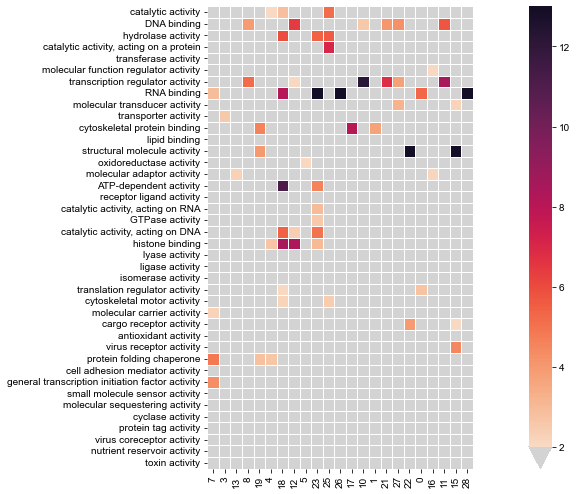

In [32]:
myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')

pvalsbylocationlog2=tmp
pvalsbylocationlog2[:] = pvalsbylocationlog2[:, myclustorder]
print(pvalsbylocationlog2)

mymask=np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0);
print(np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0))
#print(pvalsbylocation[:,mymask])

mysubfeats=[]
for i in range(0,len(mymask)):
    if mymask[i] == True:
        mysubfeats.append(myclustorder[i])
        
c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (20, 8.5)) 
sbn.heatmap(pvalsbylocationlog2[:,mymask],cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=.5)
plt.yticks(np.arange(0.5, len(allterm), 1), allterm,rotation=0) 
plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=90) 

#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_molecular_function_heatmap_by_cluster_median_sorted_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.pdf', transparent=True, bbox_inches = "tight") 


## 3.9 - Get number of IDRs by function

In [235]:
numIDRsbyfunc=[]
for a in range(0,len(eachgoacc)):
    print(allmolfunctionterm[a])
    print(len(eachgoacc[a]))
    sumallidrs=0
    for s in range(0,len(subaccs)):
        if subaccs[s] in mappedaccs:
            if subaccs[s] in eachgoacc[a]:
                sumallidrs=sumallidrs+1
    numIDRsbyfunc.append(sumallidrs)
    print(sumallidrs)
    
print(numIDRsbyfunc)

catalytic activity
5609
1686
DNA binding
2496
1932
hydrolase activity
2423
684
catalytic activity, acting on a protein
2301
1026
transferase activity
2279
894
molecular function regulator activity
2024
778
transcription regulator activity
1894
1456
RNA binding
1655
1116
molecular transducer activity
1522
237
transporter activity
1239
289
cytoskeletal protein binding
988
691
lipid binding
844
331
structural molecule activity
768
404
oxidoreductase activity
733
85
molecular adaptor activity
572
382
ATP-dependent activity
566
307
receptor ligand activity
497
60
catalytic activity, acting on RNA
409
132
GTPase activity
332
46
catalytic activity, acting on DNA
256
203
histone binding
247
326
lyase activity
197
18
ligase activity
168
20
isomerase activity
165
25
translation regulator activity
139
58
cytoskeletal motor activity
114
72
molecular carrier activity
94
23
cargo receptor activity
83
31
antioxidant activity
82
5
virus receptor activity
78
14
protein folding chaperone
65
26
cell adhe

## 3.10 - Plot p-values by sorted clusters and rows by enrichment in housing IDR

                                            Function  Number of IDRs  \
1                                        DNA binding            1932   
6                   transcription regulator activity            1456   
7                                        RNA binding            1116   
10                      cytoskeletal protein binding             691   
20                                   histone binding             326   
14                        molecular adaptor activity             382   
19                 catalytic activity, acting on DNA             203   
32  general transcription initiation factor activity              31   
25                       cytoskeletal motor activity              72   
15                            ATP-dependent activity             307   
31                   cell adhesion mediator activity              29   
3            catalytic activity, acting on a protein            1026   
24                    translation regulator activity            

[[ 1.27553771e+02  9.95786758e-01  3.71963927e-02  1.68303440e-02
   1.04712117e+00  3.92491582e+00  1.10885634e-02  3.28680611e-01
   2.46879352e-01  1.09335143e+00  6.45940024e+00  4.85657481e-01
   1.90679998e-02  1.56888448e+00  2.62843301e-01  1.86941288e-01
   1.49481207e-04  1.06620351e-05  1.13058008e-04  2.51718324e+00
   1.95347458e-03  4.07303488e+00  4.22844168e+00  3.45446207e-12
   8.93108238e-01  3.47694677e-01  1.68727565e-02  5.73487714e+00
   2.88114439e-04  5.34660921e-01  2.57483774e-02]
 [ 9.90361989e+01  6.91864713e-02  1.23461788e-01  6.27109671e-02
   1.16712523e+00  5.20475374e+00  3.63880042e-02  4.88850181e-02
   9.01437947e-01  4.29278352e-02  2.05411876e+00  4.97954821e-01
   3.14133800e-06  6.65975085e-06  4.84935137e-01  1.95546042e-02
   5.74143434e-07  5.00162868e-05  1.22839265e-03  1.22205764e+01
   3.17876392e-01  6.77180124e+00  3.72185606e+00  1.30868880e-12
   6.18674088e-01  9.53564460e-01  5.04221121e-02  8.51358924e+00
   3.92525534e-02  1.4998

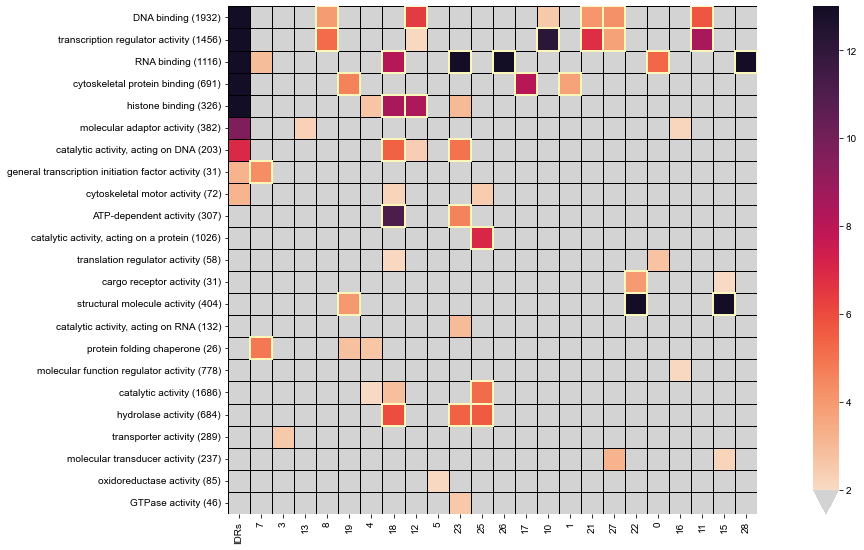

In [242]:
numkclusts=max(subclusters)+1
minIDRnum=25

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
tmp2=np.loadtxt('data/molecular_function_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt')

# Create data frame of functions, number of IDRs, enrichment of IDRs, cluster enrichment 
dfenrichfunc=pd.DataFrame()
dfenrichfunc['Function']=allmolfunctionterm
dfenrichfunc['Number of IDRs']=numIDRsbyfunc
dfenrichfunc['IDRs']=tmp2
#print(dfenrichfunc)

for i in range(0,len(myclustorder)):
    dfenrichfunc[myclustorder[i]]=tmp[:,myclustorder[i]]
    
# Only keep functions if have at least minIDRnum
dfenrichfunc=dfenrichfunc[dfenrichfunc['Number of IDRs']>=minIDRnum]

# Sort by enrichment in proteins having IDRs
dfenrichfunc=dfenrichfunc.sort_values(by=['IDRs','Number of IDRs'],ascending=False)
print(dfenrichfunc)

# Convert data to numpy array
allcolumns=dfenrichfunc.columns.values.tolist()
datacolumns=allcolumns[2:]
tmppvalsbyfunctionlog=dfenrichfunc[datacolumns].to_numpy()
print(np.shape(tmppvalsbyfunctionlog))

# Get names for plotting
sortedfuncnamesnonums=dfenrichfunc['Function'].tolist()
sortedidrnums=dfenrichfunc['Number of IDRs'].tolist()
sortedfuncnames=[]
for i in range(0,len(sortedfuncnamesnonums)):
    sortedfuncnames.append(sortedfuncnamesnonums[i]+' ('+str(sortedidrnums[i])+')')


pvalsbyfunctionlog2=tmppvalsbyfunctionlog
print(pvalsbyfunctionlog2)

mymask=np.any(pvalsbyfunctionlog2 > -math.log10(0.01), axis=0);
mymask2=np.any(pvalsbyfunctionlog2 > -math.log10(0.01), axis=1);
print(np.any(pvalsbyfunctionlog2 > -math.log10(0.01), axis=0))
#print(pvalsbylocation[:,mymask])

mysubfeats=[]
for i in range(0,len(mymask)):
    if mymask[i] == True:
        mysubfeats.append(datacolumns[i])

mysubfuncnames=[]
for i in range(0,len(mymask2)):
    if mymask2[i] == True:
        mysubfuncnames.append(sortedfuncnames[i])
        
c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (20, len(sortedfuncnames)/3)) 
tmp=pvalsbyfunctionlog2[:,mymask]
maskedvals=tmp[mymask2,:]
sbn.heatmap(maskedvals,cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=.5,linecolor='#000000')
plt.yticks(np.arange(0.5, len(mysubfuncnames), 1), mysubfuncnames,rotation=0) 
plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=90) 

# If want to account for multiple hypothesis correction using Bonferroni correction across the 30 clusters
for i in range(0,len(maskedvals)):
    for j in range(1,len(maskedvals[0])):
        if maskedvals[i][j]> -math.log10(0.01/len(myclustorder)):
            ax.add_patch(patches.Rectangle((j, i),1,1,edgecolor='#fbf6b9',fill=False,lw=2))
print(len(myclustorder))    

#plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_04//fisher_exact_test_pvals_molecular_function_heatmap_by_cluster_median_sorted_by_IDR_enrichment_f_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs_30_clusters_correction.pdf', transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_molecular_function_heatmap_by_cluster_median_sorted_by_IDR_enrichment_f_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs.pdf', transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_molecular_function_heatmap_by_cluster_median_sorted_by_IDR_enrichment_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs.pdf', transparent=True, bbox_inches = "tight") 

## 3.10b - as bubble plot

                                            Function  Number of IDRs  \
1                                        DNA binding            1932   
6                   transcription regulator activity            1456   
7                                        RNA binding            1116   
10                      cytoskeletal protein binding             691   
20                                   histone binding             326   
14                        molecular adaptor activity             382   
19                 catalytic activity, acting on DNA             203   
32  general transcription initiation factor activity              31   
25                       cytoskeletal motor activity              72   
15                            ATP-dependent activity             307   
31                   cell adhesion mediator activity              29   
3            catalytic activity, acting on a protein            1026   
24                    translation regulator activity            

meta NOT subset; don't know how to subset; dropped


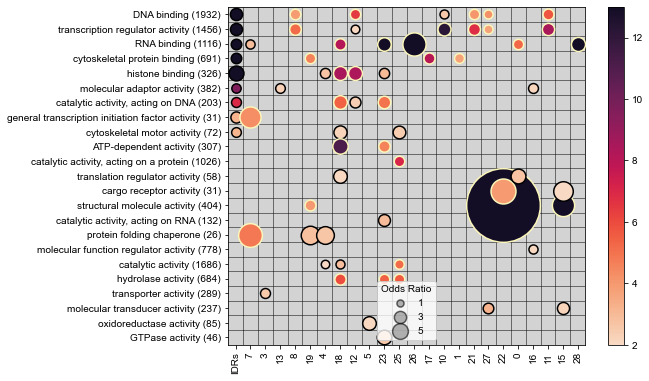

In [247]:
numkclusts=max(subclusters)+1
minIDRnum=25

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
tmp2=np.loadtxt('data/molecular_function_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt')
tmpor=np.loadtxt('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt')
tmpor2=np.loadtxt('data/molecular_function_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_odds_ratio.txt')

# Create data frame of functions, number of IDRs, enrichment of IDRs, cluster enrichment 
dfenrichfunc=pd.DataFrame()
dfenrichfunc['Function']=allmolfunctionterm
dfenrichfunc['Number of IDRs']=numIDRsbyfunc
dfenrichfunc['IDRs']=tmp2
dfenrichfunc['IDRs Odds Ratio']=tmpor2
#print(dfenrichfunc)

for i in range(0,len(myclustorder)):
    dfenrichfunc[myclustorder[i]]=tmp[:,myclustorder[i]]
    dfenrichfunc[str(myclustorder[i])+' Odds Ratio']=tmpor[:,myclustorder[i]]
    
# Only keep functions if have at least minIDRnum
dfenrichfunc=dfenrichfunc[dfenrichfunc['Number of IDRs']>=minIDRnum]

# Sort by enrichment in proteins having IDRs
dfenrichfunc=dfenrichfunc.sort_values(by=['IDRs','Number of IDRs'],ascending=False)
print(dfenrichfunc)


# Remove Clusters that have no significant enrichment 
nonsigclustnum=0
sigclustlist=[]
cols_to_drop = []
for col in myclustorder:
    if (dfenrichfunc[col] <= -math.log10(0.01)).all(): # Check if ALL values in the column are less than x
        cols_to_drop.append(col)
        cols_to_drop.append(str(col)+' Odds Ratio')
        nonsigclustnum=nonsigclustnum+1
    else:
        sigclustlist.append(col)
        
# Remove functions that have no significant enrichment
condition = (dfenrichfunc[['IDRs']+myclustorder] <= -math.log10(0.01)).all(axis=1)

# Filter the DataFrame to keep rows where the condition is NOT met
dfenrichfunc = dfenrichfunc[~condition]
        
dfenrichfunc = dfenrichfunc.drop(columns=cols_to_drop)
enrichfunclist=dfenrichfunc['Function'].tolist()
#print(dfenrichfunc) 
#print(sigclustlist)
#hi

# Get names for plotting
sortedfuncnamesnonums=dfenrichfunc['Function'].tolist()
sortedidrnums=dfenrichfunc['Number of IDRs'].tolist()
sortedfuncnames=[]
for i in range(0,len(sortedfuncnamesnonums)):
    sortedfuncnames.append(sortedfuncnamesnonums[i]+' ('+str(sortedidrnums[i])+')')


c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

szscale=50
fig, ax = plt.subplots(figsize=((len(sigclustlist)+1)/3,len(enrichfunclist)/3.7))
ax.set_facecolor('lightgrey')
for a in range(0,len(enrichfunclist)):
    ax.plot([-0.5,len(sigclustlist)-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=-1,linewidth=0.5)
    ax.plot([-1.5,-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=0,linewidth=0.5)
    for c in range(-1,len(sigclustlist)):
        if a==0:
            ax.plot([c+0.5,c+0.5],[0.5,-1*(len(enrichfunclist))+0.5],'-',color='black',zorder=0,linewidth=0.5)
            
        # Plot enrichment of IDRs in a function
        if c==-1:
            if dfenrichfunc['IDRs'].tolist()[a] > -math.log10(0.01): 
                if dfenrichfunc['IDRs Odds Ratio'].tolist()[a]>5:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichfunc['IDRs Odds Ratio'].tolist()[a]*szscale,c=dfenrichfunc['IDRs'].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=1,linewidths=1.5)
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichfunc['IDRs Odds Ratio'].tolist()[a]*szscale,c=dfenrichfunc['IDRs'].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=2,linewidths=1.5)                    

        # Plot enrichment of IDRs of a given cluster in a function
        else:
            if dfenrichfunc[sigclustlist[c]].tolist()[a] > -math.log10(0.01):
                if dfenrichfunc[sigclustlist[c]].tolist()[a] > -math.log10(0.01/len(myclustorder)):
                    if dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>15:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichfunc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=1,linewidths=1.5)
                    elif dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>5:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichfunc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=2,linewidths=1.5)
                        print(enrichfunclist[a]+' '+str(sigclustlist[c]))
                        print(dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale)
                    else:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichfunc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=3,linewidths=1.5)                    
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichfunc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichfunc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=3,linewidths=1.5)

        
#plt.colorbar(myscatter,extend='min',ax=ax)
plt.colorbar(myscatter,ax=ax)
ax.set_yticks(np.arange(0, -1*(len(sortedfuncnames)), -1), sortedfuncnames,rotation=0) 
ax.set_xticks(np.arange(-1, len(sigclustlist), 1), ['IDRs']+sigclustlist,rotation=90) 
ax.set_ylim([-1*(len(enrichfunclist))+0.5,0.5])
ax.set_xlim([-1.5,len(sigclustlist)-0.5])

size_val_arr=np.array([1,3,5])
for size_val, label_text in [(szscale*size_val_arr[0], "1"), (szscale*size_val_arr[1], "3"), (szscale*size_val_arr[2], "5")]:
    ax.scatter([], [], s=size_val, color='gray', edgecolor='black',linewidth=1.5, alpha=0.6, label=f'{label_text}')
    print(size_val)
plt.legend(scatterpoints=1, frameon=True, title="Odds Ratio")

#plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_08/fisher_exact_test_pvals_molecular_function_heatmap_by_cluster_median_sorted_by_IDR_enrichment_f_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs_30_clusters_correction_bubble.pdf', transparent=True, bbox_inches = "tight") 


## 3.11 - Add data to excel file

In [248]:
#funcdf=pd.DataFrame()
#funcdf['Function']=mysubfuncnames
#for i in range(0,len(mysubfeats)):
#    funcdf[mysubfeats[i]]=maskedvals[:,i]
    
#print(funcdf)

#with pd.ExcelWriter('../Supplementary_Tables/Table_S1.xlsx', engine='openpyxl',mode='a') as writer:
#    funcdf.to_excel(writer,sheet_name='n2Fig_1C')

#print(dfenrichfunc)
#dfenrichfunc.to_excel('data/molecular_function_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.xlsx')

                                            Function  Number of IDRs  \
1                                        DNA binding            1932   
6                   transcription regulator activity            1456   
7                                        RNA binding            1116   
10                      cytoskeletal protein binding             691   
20                                   histone binding             326   
14                        molecular adaptor activity             382   
19                 catalytic activity, acting on DNA             203   
32  general transcription initiation factor activity              31   
25                       cytoskeletal motor activity              72   
15                            ATP-dependent activity             307   
3            catalytic activity, acting on a protein            1026   
24                    translation regulator activity              58   
27                           cargo receptor activity            

## 3.12 - Get function by accession

In [13]:
### For subset of interest ###
subfunctionsbyuni=[]

for s in range(0,len(subaccs)):
    tmplist=[]
    for a in range(0,len(eachgoacc)):
            if subaccs[s] in eachgoacc[a]:
                tmplist.append(allmolfunctionterm[a])
    subfunctionsbyuni.append(tmplist)

subfunctionsbyunistring=[]
for i in range(0,len(subfunctionsbyuni)):
    subfunctionsbyunistring.append(', '.join(subfunctionsbyuni[i]))

print(subfunctionsbyunistring)

### For subset of interest with no distance restraint ###
subfunctionsbyuniNODIST=[]

for s in range(0,len(subaccsNODIST)):
    tmplist=[]
    for a in range(0,len(eachgoacc)):
            if subaccsNODIST[s] in eachgoacc[a]:
                tmplist.append(allmolfunctionterm[a])
    subfunctionsbyuniNODIST.append(tmplist)

subfunctionsbyunistringNODIST=[]
for i in range(0,len(subfunctionsbyuniNODIST)):
    subfunctionsbyunistringNODIST.append(', '.join(subfunctionsbyuniNODIST[i]))

print(subfunctionsbyunistringNODIST)

['', '', 'molecular function regulator activity', 'structural molecule activity', 'structural molecule activity', 'structural molecule activity', '', 'structural molecule activity', 'structural molecule activity', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'molecular adaptor activity', 'DNA binding, general transcription initiation factor activity', 'general transcription initiation factor activity', 'general transcription initiation factor activity', 'molecular function regulator activity', 'molecular function regulator activity', 'catalytic activity, catalytic activity, acting on a protein, transferase activity', 'DNA binding, transcription regulator activity', 'RNA binding', 'RNA binding', 'catalytic activity, catalytic activity, acting on a protein, oxidoreductase activity, small molecule sensor activity', 'DNA binding, transcription regulator activity', 'DNA binding, transcription regulator activity', '', '', '', '', ''

['', '', 'molecular function regulator activity', 'structural molecule activity', 'structural molecule activity', 'structural molecule activity', '', 'structural molecule activity', 'structural molecule activity', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'RNA binding', 'molecular adaptor activity', 'DNA binding, general transcription initiation factor activity', 'general transcription initiation factor activity', 'general transcription initiation factor activity', 'molecular function regulator activity', 'molecular function regulator activity', 'catalytic activity, catalytic activity, acting on a protein, transferase activity', 'RNA binding', 'DNA binding, transcription regulator activity', 'RNA binding', 'RNA binding', 'catalytic activity, catalytic activity, acting on a protein, transferase activity', 'catalytic activity, catalytic activity, acting on a protein, oxidoreductase activity, small molecule sensor activity', 'DNA binding, tr

## 3.13 - Get FCR for RNA and DNA binding proteins

In [17]:
## analzying for just subset with cluster distance cutoff ##
mybind=[]
myfcr=[]
mygenes=[]
myaccs=[]
rnaenrichclusts=[26,23,28,18,0,7]
dnaenrichclusts=[12,11,27,21,8,10]
for s in range(0,len(subfunctionsbyunistring)):
    currseq=subseqs[s]
    SeqOb=SequenceParameters(currseq)
    myfcr.append(SeqOb.get_FCR())
    mybind.append('All')
    mygenes.append(subgeneswnums[s])
    myaccs.append(subaccs[s])
    if 'RNA binding' in subfunctionsbyunistring[s]:
        myfcr.append(SeqOb.get_FCR())
        mybind.append('RNA binding')
        mygenes.append(subgeneswnums[s])
        myaccs.append(subaccs[s])
        if subclusters[s] in rnaenrichclusts:
            myfcr.append(SeqOb.get_FCR())
            mybind.append('RNA binding: '+str(subclusters[s]))
            mygenes.append(subgeneswnums[s])
            myaccs.append(subaccs[s])
    if 'DNA binding' in subfunctionsbyunistring[s]:
        myfcr.append(SeqOb.get_FCR())
        mybind.append('DNA binding')
        mygenes.append(subgeneswnums[s])
        myaccs.append(subaccs[s])
        if subclusters[s] in dnaenrichclusts:
            myfcr.append(SeqOb.get_FCR())
            mybind.append('DNA binding: '+str(subclusters[s]))
            mygenes.append(subgeneswnums[s])
            myaccs.append(subaccs[s])
        
dfnbind=pd.DataFrame()
dfnbind['Gene']=mygenes
dfnbind['Uniprot']=myaccs
dfnbind['Type']=mybind
dfnbind['FCR']=myfcr
print(dfnbind)

print(dfnbind[dfnbind['Type']=='All'])

                 Gene Uniprot         Type       FCR
0      KRTAP4-16 IDR1  G5E9R7          All  0.037736
1          TULP4 IDR7  Q9NRJ4          All  0.397849
2        PPP4R3B IDR1  Q5MIZ7          All  0.364286
3           MEPE IDR1  Q9NQ76          All  0.339286
4           MEPE IDR3  Q9NQ76          All  0.333333
...               ...     ...          ...       ...
12508   ARHGEF18 IDR6  Q6ZSZ5          All  0.195652
12509     YTHDF3 IDR1  Q7Z739          All  0.200000
12510     YTHDF3 IDR1  Q7Z739  RNA binding  0.200000
12511     YTHDF3 IDR2  Q7Z739          All  0.098160
12512     YTHDF3 IDR2  Q7Z739  RNA binding  0.098160

[12513 rows x 4 columns]
                 Gene Uniprot Type       FCR
0      KRTAP4-16 IDR1  G5E9R7  All  0.037736
1          TULP4 IDR7  Q9NRJ4  All  0.397849
2        PPP4R3B IDR1  Q5MIZ7  All  0.364286
3           MEPE IDR1  Q9NQ76  All  0.339286
4           MEPE IDR3  Q9NQ76  All  0.333333
...               ...     ...  ...       ...
12506   ARHGEF18 IDR1  

## 3.14 - Plot FCR for RNA and DNA binding proteins

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

RNA binding v.s. DNA binding: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=3.529e-26 U_stat=1.328e+06
All v.s. RNA binding: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.417e-33 U_stat=3.713e+06
All v.s. DNA binding: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.918e-01 U_stat=8.436e+06


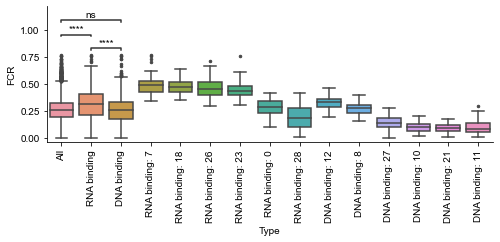

In [15]:
from statannot import add_stat_annotation

plt.figure(figsize=(8,2.5))
myorder=['All','RNA binding','DNA binding','RNA binding: 7','RNA binding: 18','RNA binding: 26','RNA binding: 23','RNA binding: 0','RNA binding: 28','DNA binding: 12','DNA binding: 8','DNA binding: 27','DNA binding: 10','DNA binding: 21','DNA binding: 11']
ax=sbn.boxplot(x="Type", y="FCR", data=dfnbind, order=myorder, dodge=False, flierprops={"marker": "."})
#sbn.boxplot(x="Localization", y="Frac K", data=df18, hue='Localization',order=['Nucleoli','Nucleoplasm','Nuclear speckles','Other'],dodge=False)
plt.xticks(rotation=90) 

add_stat_annotation(ax, data=dfnbind, x='Type', y='FCR', order=myorder,
                    box_pairs=[('RNA binding', 'DNA binding'),('RNA binding', 'All'),('DNA binding', 'All')],
                    test='Mann-Whitney', text_format='star', loc='inside', verbose=2)

ax.spines[['right', 'top']].set_visible(False)

#plt.savefig('Figures/2024_02/FCR_boxplots_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_All_RNAbinding_DNAbinding.pdf', transparent=True, bbox_inches = "tight") 


## 3.15 - Add Data to excel file

In [16]:
#with pd.ExcelWriter('../Supplementary_Tables/Table_S1.xlsx', engine='openpyxl',mode='a') as writer:
#    dfnbind.to_excel(writer,sheet_name='Fig_1D')
    
#dfnbind.to_excel('data/FCR_all_RNAbinding_DNAbinding.xlsx')

# Part 4: Get enrichment of Biological Process by Cluster

## 4.1 - Load in GO information from https://go.princeton.edu/cgi-bin/GOTermMapper

In [249]:
GOtable=pd.read_table('../general_data/GO_Terms/GO_Process_Slim.txt')

print(GOtable)

          GOID                                       TERM  \
0   GO:0023052                                  signaling   
1   GO:0048856           anatomical structure development   
2   GO:0030154                       cell differentiation   
3   GO:0006355  regulation of DNA-templated transcription   
4   GO:0002376                      immune system process   
..         ...                                        ...   
67  GO:0007031                    peroxisome organization   
68  GO:0071941           nitrogen cycle metabolic process   
69  GO:0071554       cell wall organization or biogenesis   
70  GO:0015979                             photosynthesis   
71  GO:0061007             hepaticobiliary system process   

    NUM_LIST_ANNOTATIONS  LIST_SIZE CLUSTER_FREQUENCY  TOTAL_NUM_ANNOTATIONS  \
0                   6370      18464            34.50%                   6451   
1                   5810      18464            31.47%                   5835   
2                   4274   

## 4.2 - Get all unique biological processes

In [250]:
allgo=GOtable['GOID'].tolist()
allterm=GOtable['TERM'].tolist()
allgenegroups=GOtable['ANNOTATED_GENES'].tolist()
allbioprocessterm=allterm

print(allterm)
print(len(allgenegroups[1]))
print(len(allgenegroups))
print(allgenegroups[1])

['signaling', 'anatomical structure development', 'cell differentiation', 'regulation of DNA-templated transcription', 'immune system process', 'programmed cell death', 'cell motility', 'protein-containing complex assembly', 'transmembrane transport', 'vesicle-mediated transport', 'cytoskeleton organization', 'nervous system process', 'cell adhesion', 'reproductive process', 'lipid metabolic process', 'defense response to other organism', 'carbohydrate derivative metabolic process', 'protein catabolic process', 'mitotic cell cycle', 'intracellular protein transport', 'membrane organization', 'inflammatory response', 'cell junction organization', 'chromatin organization', 'mRNA metabolic process', 'DNA repair', 'nucleobase-containing small molecule metabolic process', 'circulatory system process', 'DNA-templated transcription', 'autophagy', 'carbohydrate metabolic process', 'mitochondrion organization', 'generation of precursor metabolites and energy', 'chromosome segregation', 'cilium 

## 4.3 - Get mapped accessions

In [251]:
# Load in mapping of accessions to ensemble

allgoacc=[]
eachgoacc=[]
for g in allgenegroups:
    tmp=g.split(',')
    tmpacc=[]
    for i in tmp:
        tmpacc.append(i.strip())
        allgoacc.append(i.strip())
    eachgoacc.append(tmpacc)

print(len(eachgoacc))

mappedaccs=[]
for f in range(0,len(accs_all_human)):
    if accs_all_human[f] in allgoacc:
        mappedaccs.append(accs_all_human[f])
            

print(len(accs_all_human))
print('Number of mapped accessions '+str(len(mappedaccs)))

72
20882
Number of mapped accessions 16570


## 4.4 - Get biological process enrichment by cluster

In [252]:
pvalsbylocation=np.zeros((len(eachgoacc)))
pvalsbylocationlog=np.zeros((len(eachgoacc)))
oddsratiobylocation=np.zeros((len(eachgoacc)))

for a in range(0,len(eachgoacc)):
    print(allbioprocessterm[a])
    sumallidrs=0
    
    # For each process determine if IDRs are enriched there
    subfeatureyes=0
    subfeatureno=0
    restfeatureyes=0
    restfeatureno=0
    
    for s in range(0,len(accs_all_human)):
        if accs_all_human[s] in mappedaccs:
            if accs_all_human[s] in eachgoacc[a]: # if in process
                if accs_all_human[s] in subaccsNODIST: # if houses IDR
                        subfeatureyes=subfeatureyes+1
                        sumallidrs=sumallidrs+1
                else:
                    subfeatureno=subfeatureno+1
            else:
                if accs_all_human[s] in subaccsNODIST:
                    restfeatureyes=restfeatureyes+1
                else:
                    restfeatureno=restfeatureno+1
                
    print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

    # defining the table
    if subfeatureyes+restfeatureyes>0:
        data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
        print(data)
        # One-sided greater used to test if greater occurrence in nucleolus
        res = fisher_exact(data, alternative='greater')
        print(res[1])
        pvalsbylocation[a]=res[1]
        pvalsbylocationlog[a]=-math.log10(res[1])
        oddsratiobylocation[a]=res[0]
            
    print('Number of IDRs in '+allbioprocessterm[a]+' '+str(subfeatureyes+subfeatureno))
    print(sumallidrs)

print(pvalsbylocation)

signaling
16570
[[1997, 4373], [3193, 7007]]
0.48181605152527957
Number of IDRs in signaling 6370
1997
anatomical structure development
16570
[[2220, 3590], [2970, 7790]]
2.0294048001011538e-44
Number of IDRs in anatomical structure development 5810
2220
cell differentiation
16570
[[1682, 2592], [3508, 8788]]
9.915890188969746e-39
Number of IDRs in cell differentiation 4274
1682
regulation of DNA-templated transcription
16570
[[1658, 1728], [3532, 9652]]
2.504148832922532e-129
Number of IDRs in regulation of DNA-templated transcription 3386
1658
immune system process
16570
[[696, 1995], [4494, 9385]]
0.9999999999899826
Number of IDRs in immune system process 2691
696
programmed cell death
16570
[[675, 1303], [4515, 10077]]
0.002379976878603033
Number of IDRs in programmed cell death 1978
675
cell motility
16570
[[573, 1108], [4617, 10272]]
0.005595325032835386
Number of IDRs in cell motility 1681
573
protein-containing complex assembly
16570
[[562, 1001], [4628, 10379]]
2.2451300093773

16570
[[30, 73], [5160, 11307]]
0.7188711628258504
Number of IDRs in digestive system process 103
30
endocrine process
16570
[[21, 71], [5169, 11309]]
0.9724233005236553
Number of IDRs in endocrine process 92
21
snRNA metabolic process
16570
[[32, 25], [5158, 11355]]
8.89669814987932e-05
Number of IDRs in snRNA metabolic process 57
32
respiratory system process
16570
[[12, 26], [5178, 11354]]
0.5473197804943166
Number of IDRs in respiratory system process 38
12
peroxisome organization
16570
[[11, 25], [5179, 11355]]
0.6015788111278619
Number of IDRs in peroxisome organization 36
11
nitrogen cycle metabolic process
16570
[[3, 10], [5187, 11370]]
0.8250182669319097
Number of IDRs in nitrogen cycle metabolic process 13
3
cell wall organization or biogenesis
16570
[[0, 0], [5190, 11380]]
1.0
Number of IDRs in cell wall organization or biogenesis 0
0
photosynthesis
16570
[[0, 0], [5190, 11380]]
1.0
Number of IDRs in photosynthesis 0
0
hepaticobiliary system process
16570
[[0, 0], [5190, 113

## 4.5 - save p-values

In [253]:
#np.savetxt('data/biological_process_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt', pvalsbylocationlog)
#np.savetxt('data/biological_process_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_odds_ratio.txt', oddsratiobylocation)

## 4.6 - Get biological process enrichment by cluster

In [254]:
numkclusts=max(subclusters)+1

pvalsbylocation=np.zeros((len(eachgoacc),numkclusts))
pvalsbylocationlog=np.zeros((len(eachgoacc),numkclusts))
oddsratiobylocation=np.zeros((len(eachgoacc),numkclusts))

for a in range(0,len(eachgoacc)):
    sumallidrs=0
    for c in range(0,numkclusts):
        print(allterm[a])
        print('Cluster_'+str(c))
        midx = [i for i, x in enumerate(subclusters) if x == c]
        
        topaccs=[]
        for i in midx:
            topaccs.append(subaccswnums[i])
        
        #print(topaccs)
    
        # For each location determine if that feature is enriched there
        subfeatureyes=0
        subfeatureno=0
        restfeatureyes=0
        restfeatureno=0
        for s in range(0,len(subaccs)):
            if subaccs[s] in mappedaccs:
                if subaccs[s] in eachgoacc[a]:
                    if subaccswnums[s] in topaccs:
                        subfeatureyes=subfeatureyes+1
                        sumallidrs=sumallidrs+1
                    else:
                        subfeatureno=subfeatureno+1
                else:
                    if subaccswnums[s] in topaccs:
                        restfeatureyes=restfeatureyes+1
                    else:
                        restfeatureno=restfeatureno+1

        print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

        # defining the table
        if subfeatureyes+restfeatureyes>0:
            data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
            print(data)
            # One-sided greater used to test if greater occurrence in nucleolus
            res = fisher_exact(data, alternative='greater')
            print(res[1])
            pvalsbylocation[a,c]=res[1]
            pvalsbylocationlog[a,c]=-math.log10(res[1])
            oddsratiobylocation[a,c]=res[0]
            
    print('Number of IDRs in '+allterm[a]+' '+str(subfeatureyes+subfeatureno))
    print(sumallidrs)

print(pvalsbylocation)



signaling
Cluster_0
7058
[[76, 2642], [129, 4211]]
0.6906230924660757
signaling
Cluster_1
7058
[[112, 2606], [158, 4182]]
0.16854777756862288
signaling
Cluster_2
7058
[[34, 2684], [57, 4283]]
0.6282350711804672
signaling
Cluster_3
7058
[[163, 2555], [187, 4153]]
0.0009823375842787506
signaling
Cluster_4
7058
[[104, 2614], [174, 4166]]
0.6713198947755247
signaling
Cluster_5
7058
[[46, 2672], [97, 4243]]
0.9530003976520101
signaling
Cluster_6
7058
[[198, 2520], [217, 4123]]
5.240361108604482e-05
signaling
Cluster_7
7058
[[70, 2648], [136, 4204]]
0.9242989858131796
signaling
Cluster_8
7058
[[35, 2683], [58, 4282]]
0.6080260989945651
signaling
Cluster_9
7058
[[115, 2603], [223, 4117]]
0.9643929349065681
signaling
Cluster_10
7058
[[78, 2640], [84, 4256]]
0.00723598678222438
signaling
Cluster_11
7058
[[58, 2660], [84, 4256]]
0.3101806504340589
signaling
Cluster_12
7058
[[71, 2647], [148, 4192]]
0.9755017289161854
signaling
Cluster_13
7058
[[137, 2581], [128, 4212]]
6.101823858040279e-06
sign

7058
[[155, 2305], [260, 4338]]
0.14775012871166848
regulation of DNA-templated transcription
Cluster_7
7058
[[80, 2380], [126, 4472]]
0.12696484676431394
regulation of DNA-templated transcription
Cluster_8
7058
[[49, 2411], [44, 4554]]
0.0002897585818552791
regulation of DNA-templated transcription
Cluster_9
7058
[[90, 2370], [248, 4350]]
0.9996322202111501
regulation of DNA-templated transcription
Cluster_10
7058
[[91, 2369], [71, 4527]]
1.662809986274788e-08
regulation of DNA-templated transcription
Cluster_11
7058
[[87, 2373], [55, 4543]]
8.36930998375233e-11
regulation of DNA-templated transcription
Cluster_12
7058
[[111, 2349], [108, 4490]]
7.49785499969439e-07
regulation of DNA-templated transcription
Cluster_13
7058
[[80, 2380], [185, 4413]]
0.9557271632142943
regulation of DNA-templated transcription
Cluster_14
7058
[[80, 2380], [140, 4458]]
0.34050618417321976
regulation of DNA-templated transcription
Cluster_15
7058
[[23, 2437], [85, 4513]]
0.9993113284037364
regulation of D

7058
[[16, 744], [146, 6152]]
0.6821618048979542
cell motility
Cluster_11
7058
[[13, 747], [129, 6169]]
0.7729861334068627
cell motility
Cluster_12
7058
[[19, 741], [200, 6098]]
0.8717455074071938
cell motility
Cluster_13
7058
[[34, 726], [231, 6067]]
0.15775954956410587
cell motility
Cluster_14
7058
[[22, 738], [198, 6100]]
0.6781608374688364
cell motility
Cluster_15
7058
[[15, 745], [93, 6205]]
0.18217526534685208
cell motility
Cluster_16
7058
[[37, 723], [171, 6127]]
0.0013514968216858888
cell motility
Cluster_17
7058
[[41, 719], [316, 5982]]
0.35252570275760753
cell motility
Cluster_18
7058
[[17, 743], [192, 6106]]
0.9175799988192196
cell motility
Cluster_19
7058
[[23, 737], [223, 6075]]
0.7960731151630165
cell motility
Cluster_20
7058
[[35, 725], [223, 6075]]
0.08755559069424045
cell motility
Cluster_21
7058
[[21, 739], [106, 6192]]
0.02954268828337846
cell motility
Cluster_22
7058
[[5, 755], [97, 6201]]
0.9888383869583378
cell motility
Cluster_23
7058
[[18, 742], [267, 6031]]
0.9

7058
[[22, 571], [198, 6267]]
0.22384555923385022
vesicle-mediated transport
Cluster_15
7058
[[7, 586], [101, 6364]]
0.8138449455707352
vesicle-mediated transport
Cluster_16
7058
[[18, 575], [190, 6275]]
0.4842516242133318
vesicle-mediated transport
Cluster_17
7058
[[27, 566], [330, 6135]]
0.7489106198807121
vesicle-mediated transport
Cluster_18
7058
[[10, 583], [199, 6266]]
0.9852629197429595
vesicle-mediated transport
Cluster_19
7058
[[24, 569], [222, 6243]]
0.2484417846308402
vesicle-mediated transport
Cluster_20
7058
[[21, 572], [237, 6228]]
0.5953333196419928
vesicle-mediated transport
Cluster_21
7058
[[7, 586], [120, 6345]]
0.9181769113010376
vesicle-mediated transport
Cluster_22
7058
[[9, 584], [93, 6372]]
0.4903985953446923
vesicle-mediated transport
Cluster_23
7058
[[13, 580], [272, 6193]]
0.9963790468937074
vesicle-mediated transport
Cluster_24
7058
[[55, 538], [371, 6094]]
0.0007227045607156122
vesicle-mediated transport
Cluster_25
7058
[[27, 566], [306, 6159]]
0.60857042401

7058
[[48, 670], [54, 6286]]
8.775005725806097e-22
cell adhesion
Cluster_23
7058
[[19, 699], [266, 6074]]
0.9861297208416927
cell adhesion
Cluster_24
7058
[[48, 670], [378, 5962]]
0.24240345462028734
cell adhesion
Cluster_25
7058
[[22, 696], [311, 6029]]
0.9921431421449212
cell adhesion
Cluster_26
7058
[[4, 714], [135, 6205]]
0.9997652110611616
cell adhesion
Cluster_27
7058
[[38, 680], [306, 6034]]
0.3172716361850233
cell adhesion
Cluster_28
7058
[[31, 687], [147, 6193]]
0.0018621101861834841
cell adhesion
Cluster_29
7058
[[36, 682], [305, 6035]]
0.4323661264295468
Number of IDRs in cell adhesion 718
718
reproductive process
Cluster_0
7058
[[21, 672], [184, 6181]]
0.45285817868520584
reproductive process
Cluster_1
7058
[[29, 664], [241, 6124]]
0.3313713565217661
reproductive process
Cluster_2
7058
[[6, 687], [85, 6280]]
0.894206244944779
reproductive process
Cluster_3
7058
[[37, 656], [313, 6052]]
0.34016988178085567
reproductive process
Cluster_4
7058
[[28, 665], [250, 6115]]
0.473133

...

7058
[[0, 10], [285, 6763]]
1.0
mitochondrial gene expression
Cluster_24
7058
[[1, 9], [425, 6623]]
0.4636471292230995
mitochondrial gene expression
Cluster_25
7058
[[1, 9], [332, 6716]]
0.38344885172341325
mitochondrial gene expression
Cluster_26
7058
[[0, 10], [139, 6909]]
1.0
mitochondrial gene expression
Cluster_27
7058
[[0, 10], [344, 6704]]
1.0
mitochondrial gene expression
Cluster_28
7058
[[0, 10], [178, 6870]]
1.0
mitochondrial gene expression
Cluster_29
7058
[[0, 10], [341, 6707]]
1.0
Number of IDRs in mitochondrial gene expression 10
10
cytoplasmic translation
Cluster_0
7058
[[5, 39], [200, 6814]]
0.008516024276378108
cytoplasmic translation
Cluster_1
7058
[[0, 44], [270, 6744]]
1.0
cytoplasmic translation
Cluster_2
7058
[[0, 44], [91, 6923]]
1.0
cytoplasmic translation
Cluster_3
7058
[[0, 44], [350, 6664]]
1.0
cytoplasmic translation
Cluster_4
7058
[[1, 43], [277, 6737]]
0.8302862862164597
cytoplasmic translation
Cluster_5
7058
[[3, 41], [140, 6874]]
0.05903195579481264
cyto

7058
[[6, 74], [156, 6822]]
0.00988945521407689
regulatory ncRNA-mediated gene silencing
Cluster_11
7058
[[4, 76], [138, 6840]]
0.07705029755230001
regulatory ncRNA-mediated gene silencing
Cluster_12
7058
[[2, 78], [217, 6761]]
0.7156170293235309
regulatory ncRNA-mediated gene silencing
Cluster_13
7058
[[1, 79], [264, 6714]]
0.9540005172561071
regulatory ncRNA-mediated gene silencing
Cluster_14
7058
[[3, 77], [217, 6761]]
0.45724232568865697
regulatory ncRNA-mediated gene silencing
Cluster_15
7058
[[0, 80], [108, 6870]]
1.0
regulatory ncRNA-mediated gene silencing
Cluster_16
7058
[[4, 76], [204, 6774]]
0.20964269782466605
regulatory ncRNA-mediated gene silencing
Cluster_17
7058
[[3, 77], [354, 6624]]
0.7778388464645608
regulatory ncRNA-mediated gene silencing
Cluster_18
7058
[[0, 80], [209, 6769]]
1.0
regulatory ncRNA-mediated gene silencing
Cluster_19
7058
[[1, 79], [245, 6733]]
0.9424079090199737
regulatory ncRNA-mediated gene silencing
Cluster_20
7058
[[1, 79], [257, 6721]]
0.950025

7058
[[0, 8], [108, 6942]]
1.0
vitamin metabolic process
Cluster_16
7058
[[0, 8], [208, 6842]]
1.0
vitamin metabolic process
Cluster_17
7058
[[0, 8], [357, 6693]]
1.0
vitamin metabolic process
Cluster_18
7058
[[0, 8], [209, 6841]]
1.0
vitamin metabolic process
Cluster_19
7058
[[1, 7], [245, 6805]]
0.24719651922632357
vitamin metabolic process
Cluster_20
7058
[[0, 8], [258, 6792]]
1.0
vitamin metabolic process
Cluster_21
7058
[[0, 8], [127, 6923]]
1.0
vitamin metabolic process
Cluster_22
7058
[[0, 8], [102, 6948]]
1.0
vitamin metabolic process
Cluster_23
7058
[[0, 8], [285, 6765]]
1.0
vitamin metabolic process
Cluster_24
7058
[[1, 7], [425, 6625]]
0.3924358243960347
vitamin metabolic process
Cluster_25
7058
[[0, 8], [333, 6717]]
1.0
vitamin metabolic process
Cluster_26
7058
[[0, 8], [139, 6911]]
1.0
vitamin metabolic process
Cluster_27
7058
[[2, 6], [342, 6708]]
0.05457726224980772
vitamin metabolic process
Cluster_28
7058
[[0, 8], [178, 6872]]
1.0
vitamin metabolic process
Cluster_29
7

7058
[[1, 36], [205, 6816]]
0.6667389671647705
snRNA metabolic process
Cluster_8
7058
[[0, 37], [93, 6928]]
1.0
snRNA metabolic process
Cluster_9
7058
[[3, 34], [335, 6686]]
0.26009228839703363
snRNA metabolic process
Cluster_10
7058
[[0, 37], [162, 6859]]
1.0
snRNA metabolic process
Cluster_11
7058
[[0, 37], [142, 6879]]
1.0
snRNA metabolic process
Cluster_12
7058
[[1, 36], [218, 6803]]
0.6894094493907057
snRNA metabolic process
Cluster_13
7058
[[4, 33], [261, 6760]]
0.04860667780415253
snRNA metabolic process
Cluster_14
7058
[[2, 35], [218, 6803]]
0.3214148256807608
snRNA metabolic process
Cluster_15
7058
[[0, 37], [108, 6913]]
1.0
snRNA metabolic process
Cluster_16
7058
[[2, 35], [206, 6815]]
0.29798484659622926
snRNA metabolic process
Cluster_17
7058
[[1, 36], [356, 6665]]
0.8542013018484056
snRNA metabolic process
Cluster_18
7058
[[0, 37], [209, 6812]]
1.0
snRNA metabolic process
Cluster_19
7058
[[2, 35], [244, 6777]]
0.37153988109267655
snRNA metabolic process
Cluster_20
7058
[[1

7058
[[0, 4], [333, 6721]]
1.0
nitrogen cycle metabolic process
Cluster_26
7058
[[0, 4], [139, 6915]]
1.0
nitrogen cycle metabolic process
Cluster_27
7058
[[0, 4], [344, 6710]]
1.0
nitrogen cycle metabolic process
Cluster_28
7058
[[0, 4], [178, 6876]]
1.0
nitrogen cycle metabolic process
Cluster_29
7058
[[1, 3], [340, 6714]]
0.17973151144533323
Number of IDRs in nitrogen cycle metabolic process 4
4
cell wall organization or biogenesis
Cluster_0
7058
[[0, 0], [205, 6853]]
1.0
cell wall organization or biogenesis
Cluster_1
7058
[[0, 0], [270, 6788]]
1.0
cell wall organization or biogenesis
Cluster_2
7058
[[0, 0], [91, 6967]]
1.0
cell wall organization or biogenesis
Cluster_3
7058
[[0, 0], [350, 6708]]
1.0
cell wall organization or biogenesis
Cluster_4
7058
[[0, 0], [278, 6780]]
1.0
cell wall organization or biogenesis
Cluster_5
7058
[[0, 0], [143, 6915]]
1.0
cell wall organization or biogenesis
Cluster_6
7058
[[0, 0], [415, 6643]]
1.0
cell wall organization or biogenesis
Cluster_7
7058
[

## 4.7 - Save p-values

In [255]:
#np.savetxt('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt', pvalsbylocationlog)
#np.savetxt('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt', oddsratiobylocation)

## 4.8 - Plot p-values by sorted clusters

[[ 3.41875235e-02  3.00773924e+00  5.21454033e+00 ...  5.37664155e-03
   4.28063879e+00  3.53232014e-02]
 [ 1.34988315e-01  9.73945955e-02  5.32638075e-01 ...  7.54544163e-06
   5.27203763e+00  5.77243506e-01]
 [ 1.16152243e+00  9.08540877e-02  3.06361827e-01 ...  1.32976321e-03
   4.58576636e+00  1.31558726e+00]
 ...
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
[ True  True  True False  True  True  True  True  True  True False  True
  True  True  True  True False  True  True  True  True  True  True  True
  True  True  True  True  True  True]


([<matplotlib.axis.XTick at 0x145de6b52210>,
 [Text(0.5, 0, '7'),
  Text(1.5, 0, '3'),
  Text(2.5, 0, '13'),
  Text(3.5, 0, '8'),
  Text(4.5, 0, '19'),
  Text(5.5, 0, '4'),
  Text(6.5, 0, '24'),
  Text(7.5, 0, '18'),
  Text(8.5, 0, '12'),
  Text(9.5, 0, '9'),
  Text(10.5, 0, '23'),
  Text(11.5, 0, '14'),
  Text(12.5, 0, '25'),
  Text(13.5, 0, '26'),
  Text(14.5, 0, '17'),
  Text(15.5, 0, '10'),
  Text(16.5, 0, '1'),
  Text(17.5, 0, '21'),
  Text(18.5, 0, '27'),
  Text(19.5, 0, '22'),
  Text(20.5, 0, '0'),
  Text(21.5, 0, '20'),
  Text(22.5, 0, '16'),
  Text(23.5, 0, '11'),
  Text(24.5, 0, '15'),
  Text(25.5, 0, '6'),
  Text(26.5, 0, '28')])

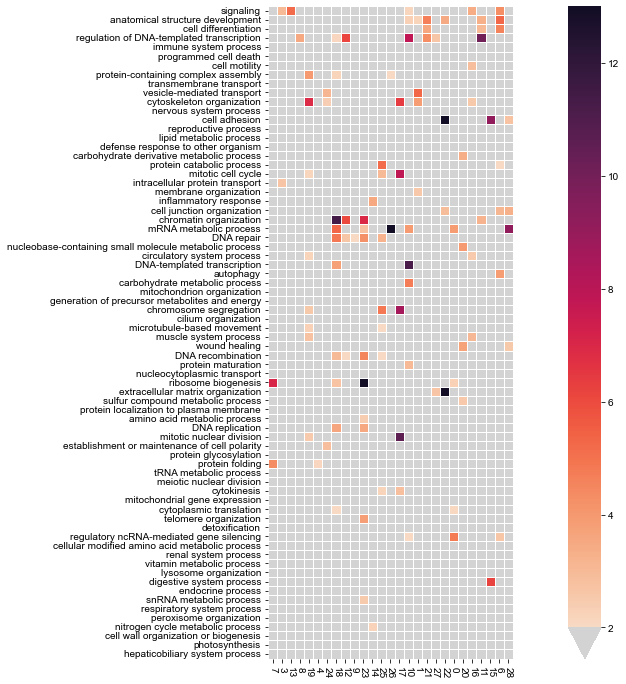

In [25]:
myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')

pvalsbylocationlog2=tmp
pvalsbylocationlog2[:] = pvalsbylocationlog2[:, myclustorder]
print(pvalsbylocationlog2)

mymask=np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0);
print(np.any(pvalsbylocationlog2 > -math.log10(0.01), axis=0))
#print(pvalsbylocation[:,mymask])

mysubfeats=[]
for i in range(0,len(mymask)):
    if mymask[i] == True:
        mysubfeats.append(myclustorder[i])

pvalsbylocationlog2=tmp
#pvalsbylocationlog2=pvalsbylocationlog


c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (20, 12)) 
sbn.heatmap(pvalsbylocationlog2[:,mymask],cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=.5)
plt.yticks(np.arange(0.5, len(allterm), 1), allterm,rotation=0) 
plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=-90) 


#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_biological_process_heatmap_by_cluster_median_sorted_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.pdf', transparent=True, bbox_inches = "tight") 


## 4.9 - Get number of IDRs by process

In [256]:
numIDRsbyproc=[]
for a in range(0,len(eachgoacc)):
    print(allbioprocessterm[a])
    print(len(eachgoacc[a]))
    sumallidrs=0
    for s in range(0,len(subaccs)):
        if subaccs[s] in mappedaccs:
            if subaccs[s] in eachgoacc[a]:
                sumallidrs=sumallidrs+1
    numIDRsbyproc.append(sumallidrs)
    print(sumallidrs)
    
print(numIDRsbyproc)

signaling
6370
2718
anatomical structure development
5810
3148
cell differentiation
4274
2382
regulation of DNA-templated transcription
3386
2460
immune system process
2691
896
programmed cell death
1978
874
cell motility
1681
760
protein-containing complex assembly
1563
826
transmembrane transport
1557
442
vesicle-mediated transport
1547
593
cytoskeleton organization
1511
1079
nervous system process
1510
509
cell adhesion
1500
718
reproductive process
1499
693
lipid metabolic process
1395
274
defense response to other organism
1169
293
carbohydrate derivative metabolic process
1045
121
protein catabolic process
1030
453
mitotic cell cycle
891
564
intracellular protein transport
865
349
membrane organization
803
263
inflammatory response
794
191
cell junction organization
753
431
chromatin organization
735
807
mRNA metabolic process
719
580
DNA repair
603
418
nucleobase-containing small molecule metabolic process
600
53
circulatory system process
585
230
DNA-templated transcription
580

## 4.10 - Plot p-values by sorted clusters and rows by enrichment in housing IDR

                                              Process  Number of IDRs  \
3           regulation of DNA-templated transcription            2460   
23                             chromatin organization             807   
24                             mRNA metabolic process             580   
1                    anatomical structure development            3148   
10                          cytoskeleton organization            1079   
28                        DNA-templated transcription             528   
2                                cell differentiation            2382   
25                                         DNA repair             418   
33                             chromosome segregation             333   
18                                 mitotic cell cycle             564   
38                                  DNA recombination             224   
47                           mitotic nuclear division             194   
46                                    DNA replicati

30


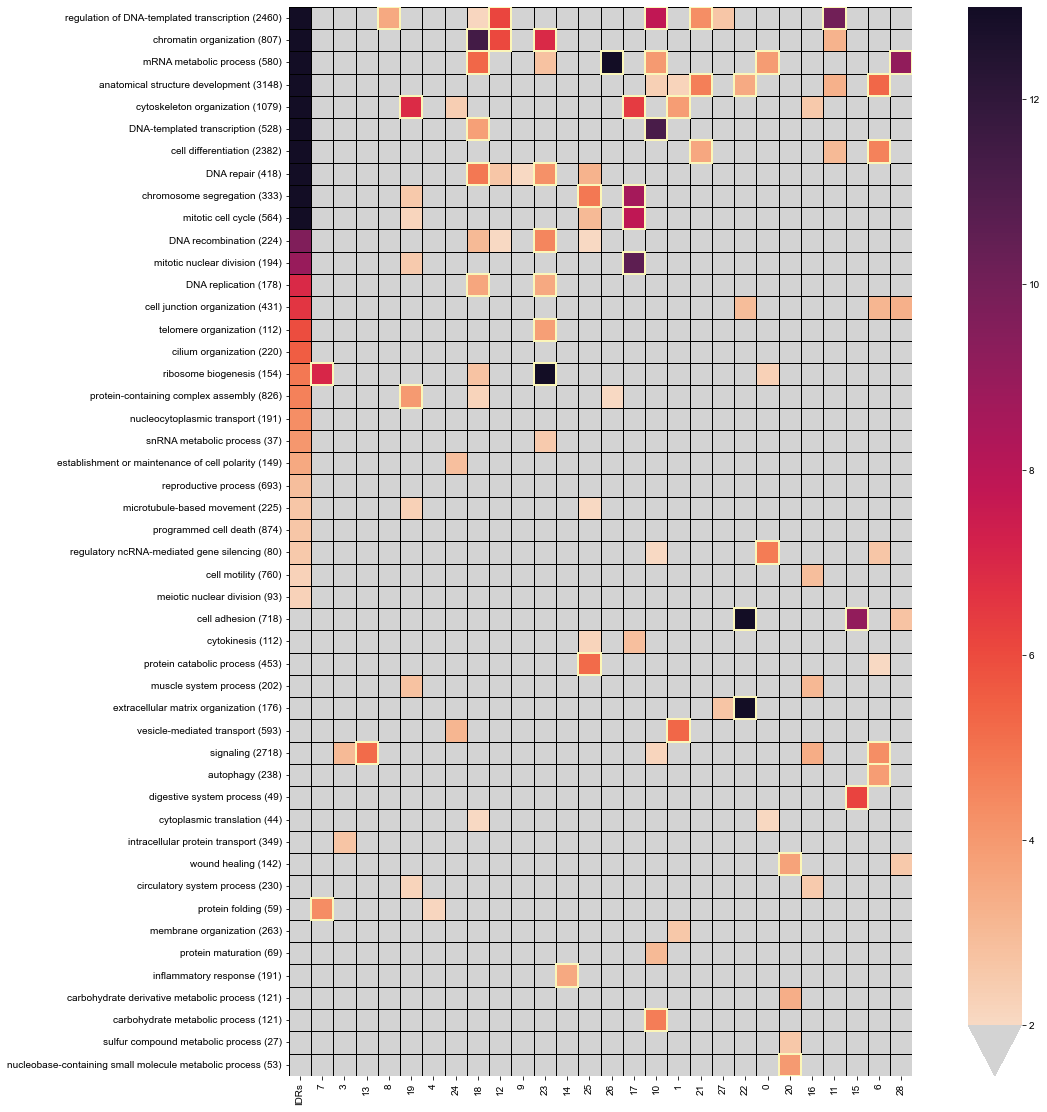

In [257]:
numkclusts=max(subclusters)+1
minIDRnum=25

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
tmp2=np.loadtxt('data/biological_process_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt')

# Create data frame of processes, number of IDRs, enrichment of IDRs, cluster enrichment 
dfenrichproc=pd.DataFrame()
dfenrichproc['Process']=allbioprocessterm
dfenrichproc['Number of IDRs']=numIDRsbyproc
dfenrichproc['IDRs']=tmp2
#print(dfenrichproc)

for i in range(0,len(myclustorder)):
    dfenrichproc[myclustorder[i]]=tmp[:,myclustorder[i]]
    
# Only keep processes if have at least minIDRnum
dfenrichproc=dfenrichproc[dfenrichproc['Number of IDRs']>=minIDRnum]

# Sort by enrichment in proteins having IDRs
dfenrichproc=dfenrichproc.sort_values(by=['IDRs','Number of IDRs'],ascending=False)
print(dfenrichproc)

# Convert data to numpy array
allcolumns=dfenrichproc.columns.values.tolist()
datacolumns=allcolumns[2:]
tmppvalsbyprocesslog=dfenrichproc[datacolumns].to_numpy()
print(np.shape(tmppvalsbyprocesslog))

# Get names for plotting
sortedprocnamesnonums=dfenrichproc['Process'].tolist()
sortedidrnums=dfenrichproc['Number of IDRs'].tolist()
sortedprocnames=[]
for i in range(0,len(sortedprocnamesnonums)):
    sortedprocnames.append(sortedprocnamesnonums[i]+' ('+str(sortedidrnums[i])+')')


pvalsbyprocesslog2=tmppvalsbyprocesslog
print(pvalsbyprocesslog2)

mymask=np.any(pvalsbyprocesslog2 > -math.log10(0.01), axis=0);
mymask2=np.any(pvalsbyprocesslog2 > -math.log10(0.01), axis=1);
print(np.any(pvalsbyprocesslog2 > -math.log10(0.01), axis=0))
#print(pvalsbylocation[:,mymask])

mysubfeats=[]
for i in range(0,len(mymask)):
    if mymask[i] == True:
        mysubfeats.append(datacolumns[i])

mysubprocnames=[]
for i in range(0,len(mymask2)):
    if mymask2[i] == True:
        mysubprocnames.append(sortedprocnames[i])
        
c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (20, len(sortedprocnames)/3)) 
tmp=pvalsbyprocesslog2[:,mymask]
maskedvals=tmp[mymask2,:]
sbn.heatmap(maskedvals,cmap=green,vmin=-math.log10(0.01), vmax=13, cbar_kws={'extend': 'min'}, square=True, linewidth=.5,linecolor='#000000')
plt.yticks(np.arange(0.5, len(mysubprocnames), 1), mysubprocnames,rotation=0) 
plt.xticks(np.arange(0.5, len(mysubfeats), 1), mysubfeats,rotation=90) 

# If want to account for multiple hypothesis correction using Bonferroni correction across the 30 clusters
for i in range(0,len(maskedvals)):
    for j in range(1,len(maskedvals[0])):
        if maskedvals[i][j]> -math.log10(0.01/len(myclustorder)):
            ax.add_patch(patches.Rectangle((j, i),1,1,edgecolor='#fbf6b9',fill=False,lw=2))
print(len(myclustorder))    

#plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_04//fisher_exact_test_pvals_biological_process_heatmap_by_cluster_median_sorted_by_IDR_enrichment_f_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs_30_clusters_correction.pdf', transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_biological_process_heatmap_by_cluster_median_sorted_by_IDR_enrichment_if_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs.pdf', transparent=True, bbox_inches = "tight") 
#plt.savefig('Figures/2024_02/fisher_exact_test_pvals_biological_process_heatmap_by_cluster_median_sorted_by_IDR_enrichment_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs.pdf', transparent=True, bbox_inches = "tight") 

## 4.10b - as bubble plot

                                              Process  Number of IDRs  \
3           regulation of DNA-templated transcription            2460   
23                             chromatin organization             807   
24                             mRNA metabolic process             580   
1                    anatomical structure development            3148   
10                          cytoskeleton organization            1079   
28                        DNA-templated transcription             528   
2                                cell differentiation            2382   
25                                         DNA repair             418   
33                             chromosome segregation             333   
18                                 mitotic cell cycle             564   
38                                  DNA recombination             224   
47                           mitotic nuclear division             194   
46                                    DNA replicati

digestive system process 15
674.0487804878048
protein folding 7
310.751269035533
nucleobase-containing small molecule metabolic process 20
277.4917853231106
50
150
250


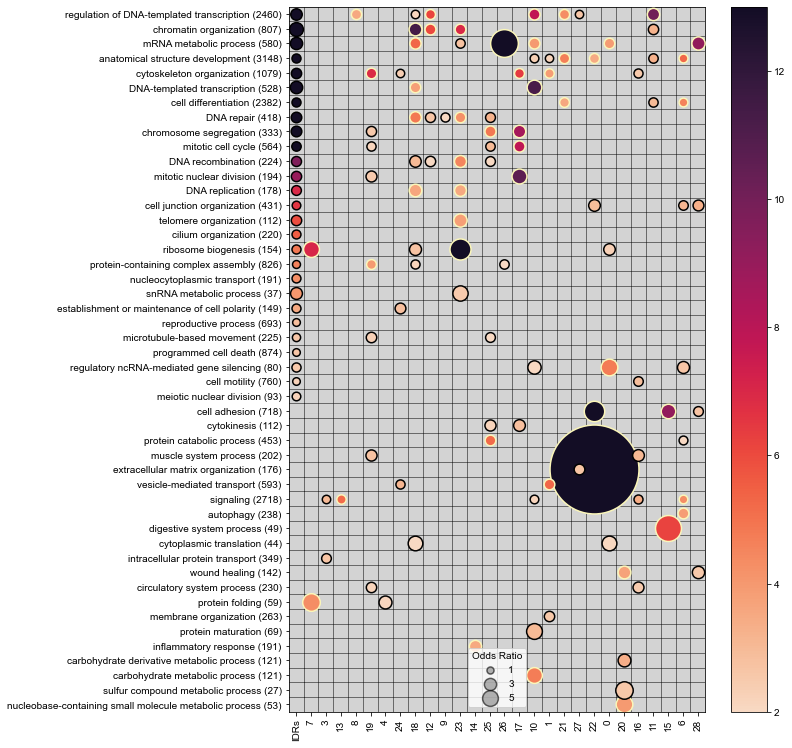

In [261]:
numkclusts=max(subclusters)+1
minIDRnum=25

myclustorder=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmp=np.loadtxt('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.txt')
tmp2=np.loadtxt('data/biological_process_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'.txt')
tmpor=np.loadtxt('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_odds_ratio.txt')
tmpor2=np.loadtxt('data/biological_process_GO_enrichment_in_IDRs_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_odds_ratio.txt')

# Create data frame of processes, number of IDRs, enrichment of IDRs, cluster enrichment 
dfenrichproc=pd.DataFrame()
dfenrichproc['Process']=allbioprocessterm
dfenrichproc['Number of IDRs']=numIDRsbyproc
dfenrichproc['IDRs']=tmp2
dfenrichproc['IDRs Odds Ratio']=tmpor2
#print(dfenrichproc)

for i in range(0,len(myclustorder)):
    dfenrichproc[myclustorder[i]]=tmp[:,myclustorder[i]]
    dfenrichproc[str(myclustorder[i])+' Odds Ratio']=tmpor[:,myclustorder[i]]
    
# Only keep processes if have at least minIDRnum
dfenrichproc=dfenrichproc[dfenrichproc['Number of IDRs']>=minIDRnum]

# Sort by enrichment in proteins having IDRs
dfenrichproc=dfenrichproc.sort_values(by=['IDRs','Number of IDRs'],ascending=False)
print(dfenrichproc)


# Remove Clusters that have no significant enrichment 
nonsigclustnum=0
sigclustlist=[]
cols_to_drop = []
for col in myclustorder:
    if (dfenrichproc[col] <= -math.log10(0.01)).all(): # Check if ALL values in the column are less than x
        cols_to_drop.append(col)
        cols_to_drop.append(str(col)+' Odds Ratio')
        nonsigclustnum=nonsigclustnum+1
    else:
        sigclustlist.append(col)
        
# Remove processes that have no significant enrichment
condition = (dfenrichproc[['IDRs']+myclustorder] <= -math.log10(0.01)).all(axis=1)

# Filter the DataFrame to keep rows where the condition is NOT met
dfenrichproc = dfenrichproc[~condition]
        
dfenrichproc = dfenrichproc.drop(columns=cols_to_drop)
enrichproclist=dfenrichproc['Process'].tolist()
#print(dfenrichproc) 
#print(sigclustlist)
#hi

# Get names for plotting
sortedprocnamesnonums=dfenrichproc['Process'].tolist()
sortedidrnums=dfenrichproc['Number of IDRs'].tolist()
sortedprocnames=[]
for i in range(0,len(sortedprocnamesnonums)):
    sortedprocnames.append(sortedprocnamesnonums[i]+' ('+str(sortedidrnums[i])+')')


c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

szscale=50
fig, ax = plt.subplots(figsize=((len(sigclustlist)+1)/3,len(enrichproclist)/3.7))
ax.set_facecolor('lightgrey')
for a in range(0,len(enrichproclist)):
    ax.plot([-0.5,len(sigclustlist)-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=-1,linewidth=0.5)
    ax.plot([-1.5,-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=0,linewidth=0.5)
    for c in range(-1,len(sigclustlist)):
        if a==0:
            ax.plot([c+0.5,c+0.5],[0.5,-1*(len(enrichproclist))+0.5],'-',color='black',zorder=0,linewidth=0.5)
            
        # Plot enrichment of IDRs in a process
        if c==-1:
            if dfenrichproc['IDRs'].tolist()[a] > -math.log10(0.01): 
                if dfenrichproc['IDRs Odds Ratio'].tolist()[a]>5:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichproc['IDRs Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc['IDRs'].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=1,linewidths=1.5)
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichproc['IDRs Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc['IDRs'].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=2,linewidths=1.5)                    

        # Plot enrichment of IDRs of a given cluster in a process
        else:
            if dfenrichproc[sigclustlist[c]].tolist()[a] > -math.log10(0.01):
                if dfenrichproc[sigclustlist[c]].tolist()[a] > -math.log10(0.01/len(myclustorder)):
                    if dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>15:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=1,linewidths=1.5)
                    elif dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]>5:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=2,linewidths=1.5)
                        print(enrichproclist[a]+' '+str(sigclustlist[c]))
                        print(dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale)
                    else:
                        myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='#fbf6b9',zorder=3,linewidths=1.5)                    
                else:
                    myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sigclustlist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sigclustlist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=13,edgecolor='black',zorder=3,linewidths=1.5)

        
#plt.colorbar(myscatter,extend='min',ax=ax)
plt.colorbar(myscatter,ax=ax)
ax.set_yticks(np.arange(0, -1*(len(sortedprocnames)), -1), sortedprocnames,rotation=0) 
ax.set_xticks(np.arange(-1, len(sigclustlist), 1), ['IDRs']+sigclustlist,rotation=90) 
ax.set_ylim([-1*(len(enrichproclist))+0.5,0.5])
ax.set_xlim([-1.5,len(sigclustlist)-0.5])

size_val_arr=np.array([1,3,5])
for size_val, label_text in [(szscale*size_val_arr[0], "1"), (szscale*size_val_arr[1], "3"), (szscale*size_val_arr[2], "5")]:
    ax.scatter([], [], s=size_val, color='gray', edgecolor='black',linewidth=1.5, alpha=0.6, label=f'{label_text}')
    print(size_val)
plt.legend(scatterpoints=1, frameon=True, title="Odds Ratio")

#plt.savefig('/project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/IDR_basis_set/Figures/2025_08/fisher_exact_test_pvals_biological_process_heatmap_by_cluster_median_sorted_by_IDR_enrichment_f_enriched_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'_gte_'+str(minIDRnum)+'_IDRs_30_clusters_correction_bubble.pdf', transparent=True, bbox_inches = "tight") 


## 4.11 - Add Data to excel file

In [262]:
#procdf=pd.DataFrame()
#procdf['Process']=mysubprocnames
#for i in range(0,len(mysubfeats)):
#    procdf[mysubfeats[i]]=maskedvals[:,i]
    
#print(procdf)

#with pd.ExcelWriter('../Supplementary_Tables/Table_S1.xlsx', engine='openpyxl',mode='a') as writer:
#    procdf.to_excel(writer,sheet_name='Fig_1E')

#print(dfenrichproc)
#dfenrichproc.to_excel('data/biological_process_GO_enrichment_by_cluster_all_human_gte_'+str(minidrlinkerlength)+'_and_nonlinkers_gte_'+str(minidrlength)+'_idrs_dist_gte_'+str(mininterclustdist)+'.xlsx')

                                              Process  Number of IDRs  \
3           regulation of DNA-templated transcription            2460   
23                             chromatin organization             807   
24                             mRNA metabolic process             580   
1                    anatomical structure development            3148   
10                          cytoskeleton organization            1079   
28                        DNA-templated transcription             528   
2                                cell differentiation            2382   
25                                         DNA repair             418   
33                             chromosome segregation             333   
18                                 mitotic cell cycle             564   
38                                  DNA recombination             224   
47                           mitotic nuclear division             194   
46                                    DNA replicati